# Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

**Mounting Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
!cp /content/drive/MyDrive/Intrusion_detection_project_folder/kaggle.json ~/.kaggle/


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install -q kaggle

# DATA SETS LINKS

In [ ]:
#https://www.dropbox.com/scl/fo/8kll7yvbgogkp0vahowvm/ADhDIC8LRFL8wHUexib3C3w?rlkey=43n570cnodtq6yls139r4yvn7&e=2&st=uronu6mh&dl=0
#https://www.kaggle.com/datasets/hassan06/nslkdd
#https://www.kaggle.com/datasets/cyberdeeplearning/ciciomt2024
#https://www.kaggle.com/datasets/amaniabourida/ton-iot
#https://www.kaggle.com/datasets/abdelmoumendbh/ciciomt2024-log-scaling-label-encoding

# DATA COLLECTION AND MERGING

NSL - KDD dataset

The NSL-KDD dataset is a refined version of the KDD Cup 1999 dataset, specifically designed for evaluating Intrusion Detection Systems (IDS). It overcomes several critical shortcomings of the original KDD dataset, such as redundant records and an uneven distribution of attack types, which often led to biased and inaccurate evaluation of machine learning models.

In essence, NSL-KDD offers a more realistic and balanced benchmark for training and testing IDS models. It helps researchers develop and assess the effectiveness of intrusion detection techniques more accurately, ultimately contributing to the creation of more robust and reliable cybersecurity solutions.

In [ ]:
# this is the link to download the dataset from kaggle
!kaggle datasets download -d hassan06/nslkdd

Dataset URL: https://www.kaggle.com/datasets/hassan06/nslkdd
License(s): unknown
  0% 0.00/13.9M [00:00<?, ?B/s]
100% 13.9M/13.9M [00:00<00:00, 1.92GB/s]


In [ ]:
!unzip -q nslkdd.zip -d nslkdd

The NSL KDD dataset has been split into train and test data

## Analysis of NSL-KDD Datasets


**KDDTrain+.txt**

This dataset contains 125,973 entries and is primarily used for training. It includes 'normal' traffic and a variety of known attack types (e.g., 'neptune', 'satan', 'ipsweep', 'smurf').

**KDDTest+.txt**

This dataset is smaller with 22,544 entries, designed for testing. Crucially, it contains several novel attack types that are not present in KDDTrain+.txt (e.g., 'mscan', 'warezmaster', 'apache2', 'processtable', 'snmpguess', 'httptunnel', 'named', 'ps', 'sendmail', 'xterm', 'xlock', 'xsnoop', 'worm', 'sqlattack', 'udpstorm').

This characteristic is intentional in NSL-KDD to evaluate how well an intrusion detection system can generalize to new, unseen threats.

In [ ]:
import os
import shutil



# Paths
src_folder = "/content/nslkdd"
dst_folder = "/content/drive/MyDrive/Datasets/nsl_kdd"

# Create the destination folder if it doesn't exist
os.makedirs(dst_folder, exist_ok=True)

# Copy the contents of the extracted folder
for item in os.listdir(src_folder):
    s = os.path.join(src_folder, item)
    d = os.path.join(dst_folder, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print(f"Extracted contents saved permanently to: {dst_folder}")

Extracted contents saved permanently to: /content/drive/MyDrive/Datasets/nsl_kdd


In [ ]:
KDD_Train = "/content/drive/MyDrive/Datasets/nsl_kdd/KDDTrain+.txt"
KDD_test = "/content/drive/MyDrive/Datasets/nsl_kdd/KDDTest+.txt"

In [ ]:
df_kdd_train = pd.read_csv(KDD_Train)
df_kdd_test = pd.read_csv(KDD_test)

In [ ]:
# taking a look on the train dataset
df_kdd_train.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [ ]:
#taking a look on the test dataset
df_kdd_test.head()

,0,tcp,private,REJ,0.1,0.2,0.3,0.4,0.5,0.6,...,0.04.1,0.06.1,0.00.3,0.00.4,0.00.5,0.00.6,1.00.2,1.00.3,neptune,21
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21


### Merging the two datasets

#### **Reasons why we are merging the two**

**Increased Data Volume**
Deep learning models typically perform much better with more data. By combining both, our new dataset will now have around a total of 148,517 records. This larger volume provides more examples for our model to learn from.

**Richer Attack Variety**
The most significant advantage of merging is the inclusion of all attack types from both the training and test sets. This means our combined dataset now covers a broader spectrum of network intrusions, including those novel attacks that a system might encounter in a real-world scenario. A model trained on this comprehensive dataset will be more robust and better equipped to identify diverse threats.

**Improved Generalization**
Exposing your deep learning model to this wider range of normal and attack patterns will help it develop better generalization capabilities, making it more effective in detecting various forms of network intrusions.

**Preprocessing for Consistency**

To make this dataset ready for deep learning and consistent with your previous hospital datasets, I've done the following:

I used the standard 43 column names for the NSL-KDD dataset (41 features + attack + level).

I've added a new label column to the merged dataset. In this label column, 'normal' traffic is assigned a value of 0, and all types of attacks are assigned a value of 1. This provides a clear binary classification target for your models.

The distribution of the new label column in our merged NSL-KDD dataset is:

**Normal** (0): 77,054 entries

**Attack** (1): 71,463 entries


This balanced distribution is beneficial for training robust intrusion detection models.

In [ ]:
import pandas as pd

# Column names for the NSL-KDD dataset
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'attack', 'level'
]

# Load KDDTrain+.txt
train_df = pd.read_csv("/content/nslkdd/KDDTrain+.txt", header=None, names=columns)

# Load KDDTest+.txt
test_df = pd.read_csv("/content/nslkdd/KDDTest+.txt", header=None, names=columns)

# Concatenate the two DataFrames
nslkdd_merged_df = pd.concat([train_df, test_df], ignore_index=True)

# Converting the 'attack' column to a binary label: 0 for 'normal', 1 for any attack type
nslkdd_merged_df['label'] = nslkdd_merged_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

# Display the value counts of the 'label' column in the merged DataFrame
print("Value counts for 'label' in the merged NSL-KDD dataset:")
print(nslkdd_merged_df['label'].value_counts())


Value counts for 'label' in the merged NSL-KDD dataset:
label
0    77054
1    71463
Name: count, dtype: int64


**Merged NSL_KDD**

In [ ]:
import os


# Define destination path
output_filename = 'nslkdd_merged_dataset.csv'
destination_folder = "/content/drive/MyDrive/Datasets/nsl_kdd"
os.makedirs(destination_folder, exist_ok=True)

# Full path to save
full_path = os.path.join(destination_folder, output_filename)

# Save the DataFrame
nslkdd_merged_df.to_csv(output_filename, index=False)

print(f"Dataset saved permanently to: {full_path}")



Dataset saved permanently to: /content/drive/MyDrive/Datasets/nsl_kdd/nslkdd_merged_dataset.csv


In [ ]:
df_nsl_kdd_merged_dataset = pd.read_csv("/content/drive/MyDrive/Datasets/nsl_kdd/nslkdd_merged_dataset.csv")

In [ ]:
df_nsl_kdd_merged_dataset.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0


checking the shape

In [ ]:
df_nsl_kdd_merged_dataset.shape

(148517, 44)

### Data Cleaning

In [ ]:
df_nsl_kdd_merged_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     148517 non-null  int64  
 1   protocol_type                148517 non-null  object 
 2   service                      148517 non-null  object 
 3   flag                         148517 non-null  object 
 4   src_bytes                    148517 non-null  int64  
 5   dst_bytes                    148517 non-null  int64  
 6   land                         148517 non-null  int64  
 7   wrong_fragment               148517 non-null  int64  
 8   urgent                       148517 non-null  int64  
 9   hot                          148517 non-null  int64  
 10  num_failed_logins            148517 non-null  int64  
 11  logged_in                    148517 non-null  int64  
 12  num_compromised              148517 non-null  int64  
 13 

In [ ]:
df_nsl_kdd_merged_dataset.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


checking if the data labels are balanced after merging the dataset

label
0    77054
1    71463
Name: count, dtype: int64


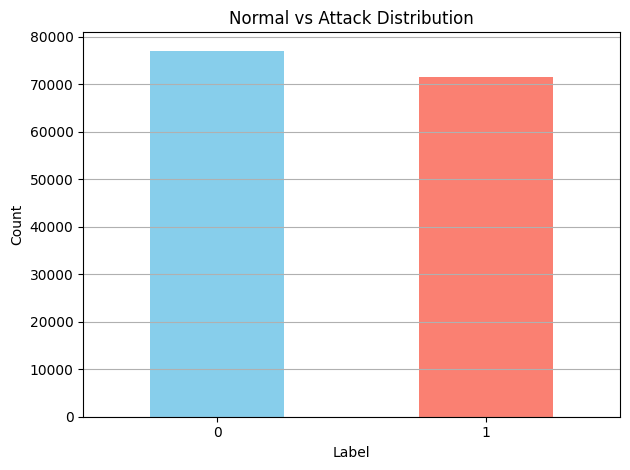

In [ ]:
# Checking the distribution of the labels
print(df_nsl_kdd_merged_dataset['label'].value_counts())

# visualizing it using a bar plot
import matplotlib.pyplot as plt

df_nsl_kdd_merged_dataset['label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Normal vs Attack Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


The distibution of labels looks great

In [ ]:
# make labels easier to interpret
df_nsl_kdd_merged_dataset['label'] = df_nsl_kdd_merged_dataset['label'].map({0: 'Normal', 1: 'Attack'})


In [ ]:
from sklearn.utils import resample

# Separate classes
df_normal = df_nsl_kdd_merged_dataset[df_nsl_kdd_merged_dataset['label'] == 'Normal']
df_attack = df_nsl_kdd_merged_dataset[df_nsl_kdd_merged_dataset['label'] == 'Attack']

# Upsample Attack to match Normal count
df_attack_upsampled = resample(
    df_attack,
    replace=True,
    n_samples=len(df_normal),  # Match number of Normal samples
    random_state=42
)

# Combine and update the original DataFrame
df_nsl_kdd_merged_dataset = pd.concat([df_normal, df_attack_upsampled])
df_nsl_kdd_merged_dataset = df_nsl_kdd_merged_dataset.sample(frac=1, random_state=42).reset_index(drop=True)



In [ ]:
# Confirm new balance
df_nsl_kdd_merged_dataset['label'].value_counts()


,count
label,
Normal,77054
Attack,77054


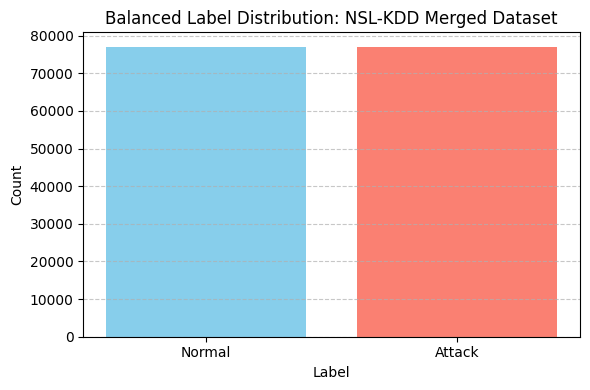

In [ ]:
import matplotlib.pyplot as plt

label_counts = df_nsl_kdd_merged_dataset['label'].value_counts()
colors = ['skyblue' if label == 'Normal' else 'salmon' for label in label_counts.index]

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values, color=colors)
plt.title('Balanced Label Distribution: NSL-KDD Merged Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Save to CSV in the current working directory
destination_folder = "/content/drive/MyDrive/Datasets/nsl_kdd"
os.makedirs(destination_folder, exist_ok=True)

# Save the merged dataset CSV
nsl_save_path = os.path.join(destination_folder, 'df_nsl_kdd_merged_dataset.csv')
df_nsl_kdd_merged_dataset.to_csv(nsl_save_path, index=False)

print(f"✅ NSL-KDD merged dataset saved to: {nsl_save_path}")


✅ NSL-KDD merged dataset saved to: /content/drive/MyDrive/Datasets/nsl_kdd/df_nsl_kdd_merged_dataset.csv


MODEL

# IOT_Intrusion dataset

The iot_intrusion dataset is a **new generation, comprehensive cybersecurity dataset** for evaluating **AI-based intrusion detection** in **IoT and IIoT environments.**

It's created from **diverse, heterogeneous data sources** (IoT/IIoT telemetry, OS logs, network traffic) collected from a **realistic, large-scale testbed**.

We chose it for our robust intrusion detection deep learning model because its **heterogeneous, realistic, and large-scale nature with diverse attack types** provides an ideal foundation for training models that can generalize well and detect a wide range of threats in complex IoT/IIoT systems.

Additionally , The dataset contains 1,191,264 IoT network instances with 47 features, covering various intrusion types such as **DDoS, DoS, Brute Force, Spoofing, Recon, Web-based attacks, and Mirai**.

It includes several subcategories under each attack type, making it well-suited for building predictive models and developing effective Intrusion Detection Systems (IDS) for IoT environments.

In [ ]:
#!pip install kaggle

In [ ]:
#/content/drive/MyDrive/kaggle.json

In [ ]:
!kaggle datasets download -d subhajournal/iotintrusion


Dataset URL: https://www.kaggle.com/datasets/subhajournal/iotintrusion
License(s): GNU Lesser General Public License 3.0
  0% 0.00/45.1M [00:00<?, ?B/s]
100% 45.1M/45.1M [00:00<00:00, 2.16GB/s]


In [ ]:
!unzip -q iotintrusion.zip -d iotintrusion

In [ ]:
import os
import shutil


# Define source and destination paths
source_path = "/content/iotintrusion/IoT_Intrusion.csv"
destination_folder = "/content/drive/MyDrive/Datasets/IoT"
destination_path = os.path.join(destination_folder, "IoT_Intrusion.csv")

# Create destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Copy the dataset to Google Drive
shutil.copy(source_path, destination_path)

print(" Dataset copied to:", destination_path)



 Dataset copied to: /content/drive/MyDrive/Datasets/IoT/IoT_Intrusion.csv


In [ ]:
df_iot_intrusion = pd.read_csv('/content/drive/MyDrive/Datasets/IoT/IoT_Intrusion.csv')
df_iot_intrusion.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.00,6.00,64.00,0.329807,0.329807,0.0,1,0,1,...,0.000000,54.00,83343831.92,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-RSTFINFlood
1,0.000000,57.04,6.33,64.00,4.290556,4.290556,0.0,0,0,0,...,2.822973,57.04,82926067.47,9.5,10.464666,4.010353,160.987842,0.05,141.55,DoS-TCP_Flood
2,0.000000,0.00,1.00,64.00,33.396799,33.396799,0.0,0,0,0,...,0.000000,42.00,83127993.93,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
3,0.328175,76175.00,17.00,64.00,4642.133010,4642.133010,0.0,0,0,0,...,0.000000,50.00,83015696.38,9.5,10.000000,0.000000,0.000000,0.00,141.55,DoS-UDP_Flood
4,0.117320,101.73,6.11,65.91,6.202211,6.202211,0.0,0,1,0,...,23.113111,57.88,82972999.18,9.5,11.346876,32.716243,3016.808286,0.19,141.55,DoS-SYN_Flood


## Data cleaning

In [ ]:
df_iot_intrusion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1048575 non-null  float64
 1   Header_Length    1048575 non-null  float64
 2   Protocol Type    1048575 non-null  float64
 3   Duration         1048575 non-null  float64
 4   Rate             1048575 non-null  float64
 5   Srate            1048575 non-null  float64
 6   Drate            1048575 non-null  float64
 7   fin_flag_number  1048575 non-null  int64  
 8   syn_flag_number  1048575 non-null  int64  
 9   rst_flag_number  1048575 non-null  int64  
 10  psh_flag_number  1048575 non-null  int64  
 11  ack_flag_number  1048575 non-null  int64  
 12  ece_flag_number  1048575 non-null  int64  
 13  cwr_flag_number  1048575 non-null  int64  
 14  ack_count        1048575 non-null  float64
 15  syn_count        1048575 non-null  float64
 16  fin_count        1

NULL VALUES

In [ ]:
df_iot_intrusion.isnull().sum()
# there was no null values found in our dataset , therefore we could proceed with label encoding

,0
flow_duration,0
Header_Length,0
Protocol Type,0
Duration,0
Rate,0
Srate,0
Drate,0
fin_flag_number,0
syn_flag_number,0
rst_flag_number,0


checking shape

In [ ]:
df_iot_intrusion.shape

(1048575, 47)

Label distribution of the dataset

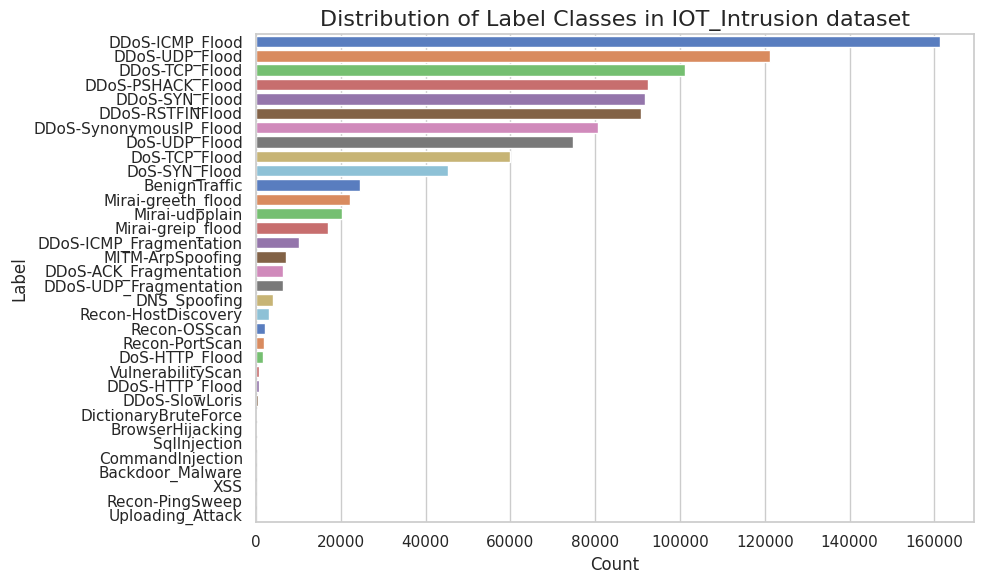

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set white background
sns.set(style="whitegrid")

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_iot_intrusion,
    y="label",
    order=df_iot_intrusion['label'].value_counts().index,
    palette="muted"
)

plt.title("Distribution of Label Classes in IOT_Intrusion dataset", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()
plt.show()



**Renaming label to normal versus the other types of attacks**

In [ ]:
# Replace 'BenignTraffic' with 'Normal' in the original dataset
df_iot_intrusion['label'] = df_iot_intrusion['label'].replace('BenignTraffic', 'Normal')

In [ ]:
df_iot_intrusion['label'].value_counts()

,count
label,
DDoS-ICMP_Flood,161281
DDoS-UDP_Flood,121205
DDoS-TCP_Flood,101293
DDoS-PSHACK_Flood,92395
DDoS-SYN_Flood,91644
DDoS-RSTFINFlood,90823
DDoS-SynonymousIP_Flood,80680
DoS-UDP_Flood,74787
DoS-TCP_Flood,59807


The normal label should be upsampled atleast to match with the highest value of attack.

**label distribution**

**unify all attack types into a single label**

In [ ]:
from sklearn.utils import resample

# Separate majority (attacks) and minority (normal) classes
df_normal = df_iot_intrusion[df_iot_intrusion['label'] == 'Normal']
df_attacks = df_iot_intrusion[df_iot_intrusion['label'] != 'Normal']

# Upsample 'Normal' to match the largest attack class
max_attack_size = df_attacks['label'].value_counts().max()

df_normal_upsampled = resample(
    df_normal,
    replace=True,
    n_samples=max_attack_size,
    random_state=42
)

# Combine back and overwrite original DataFrame
df_iot_intrusion = pd.concat([df_attacks, df_normal_upsampled])

# Shuffle the dataset
df_iot_intrusion = df_iot_intrusion.sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
# Convert all non-Normal labels to 'Attack'
df_iot_intrusion['label'] = df_iot_intrusion['label'].apply(lambda x: 'Normal' if x == 'Normal' else 'Attack')

In [ ]:
# Confirm the transformation
df_iot_intrusion['label'].value_counts()

,count
label,
Attack,1024099
Normal,161281


In [ ]:
from sklearn.utils import resample

# Separate classes
df_normal = df_iot_intrusion[df_iot_intrusion['label'] == 'Normal']
df_attack = df_iot_intrusion[df_iot_intrusion['label'] == 'Attack']

# Upsample Normal to match Attack
df_normal_upsampled = resample(
    df_normal,
    replace=True,
    n_samples=len(df_attack),  # match Attack count
    random_state=42
)

# Combine and shuffle
df_iot_intrusion = pd.concat([df_attack, df_normal_upsampled])
df_iot_intrusion = df_iot_intrusion.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Check new counts
df_iot_intrusion['label'].value_counts()

,count
label,
Normal,1024099
Attack,1024099


label
Normal    1024099
Attack    1024099
Name: count, dtype: int64


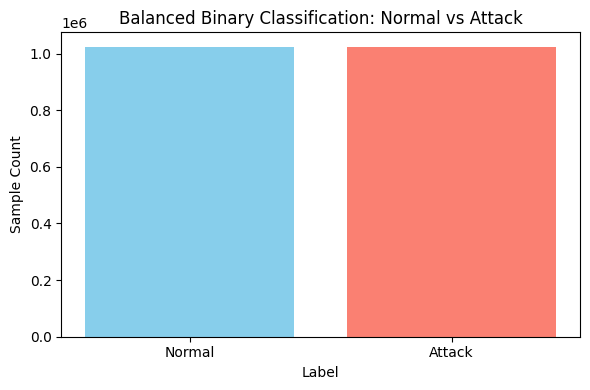

In [ ]:
import matplotlib.pyplot as plt

# Display value counts
label_counts = df_iot_intrusion['label'].value_counts()
print(label_counts)

# Plot the distribution
colors = ['skyblue' if label == 'Normal' else 'salmon' for label in label_counts.index]

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values, color=colors)
plt.title('Balanced Binary Classification: Normal vs Attack')
plt.xlabel('Label')
plt.ylabel('Sample Count')
plt.xticks(rotation=0)
plt.grid(False)
plt.tight_layout()
plt.show()


DOne , this  is very crucial step for the final merging of all datasets.

In [ ]:
#saving into drive
# Same destination folder as the main dataset
destination_folder = "/content/drive/MyDrive/Datasets/IoT"
os.makedirs(destination_folder, exist_ok=True)

# Save the final dataset CSV in the same folder
final_csv_path = os.path.join(destination_folder, 'df_iot_intrusion_final_dataset.csv')
df_iot_intrusion.to_csv(final_csv_path, index=False)

print(f"✅ Final dataset saved to: {final_csv_path}")


✅ Final dataset saved to: /content/drive/MyDrive/Datasets/IoT/df_iot_intrusion_final_dataset.csv


Mdoel fitting

#CAN-INtrusion Dataset

In [ ]:
#This is a required library to load dataset from dropbox
!pip install -q gdown

In [ ]:
# Install required library

# Dropbox direct download
dropbox_url = "https://www.dropbox.com/scl/fo/8kll7yvbgogkp0vahowvm/ADhDIC8LRFL8wHUexib3C3w?rlkey=43n570cnodtq6yls139r4yvn7&dl=1"
!gdown --fuzzy "{dropbox_url}" -O dropbox_dataset.zip

# Unzip
import zipfile
with zipfile.ZipFile("dropbox_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dropbox_dataset")

Downloading...
From: https://www.dropbox.com/scl/fo/8kll7yvbgogkp0vahowvm/ADhDIC8LRFL8wHUexib3C3w?rlkey=43n570cnodtq6yls139r4yvn7&dl=1
To: /content/dropbox_dataset.zip
100% 408M/408M [00:04<00:00, 91.9MB/s]


In [ ]:
zip_path = "/content/dropbox_dataset.zip"
extract_to = "/content/dropbox_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

In [ ]:
import os
import shutil
import zipfile
from google.colab import drive


# Paths
zip_path = "/content/dropbox_dataset.zip"
extract_to = "/content/dropbox_dataset"
drive_folder = "/content/drive/MyDrive/Datasets/dropbox_dataset"

# Extract ZIP file to temporary folder
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# Create destination folder in Drive
os.makedirs(drive_folder, exist_ok=True)

#Copy extracted contents to Drive (only the files/folders inside)
for item in os.listdir(extract_to):
    src = os.path.join(extract_to, item)
    dst = os.path.join(drive_folder, item)
    if os.path.isdir(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

print(f" Extracted contents saved to: {drive_folder}")


✅ Extracted contents saved to: /content/drive/MyDrive/Datasets/dropbox_dataset


In [ ]:
import os

# List contents inside the extracted folder
folder_path = "/content/drive/MyDrive/Datasets/dropbox_dataset"
files = os.listdir(folder_path)
print(files)


['Attack_free_dataset.txt', 'Impersonation_attack_dataset.txt', 'Fuzzy_attack_dataset.txt', 'DoS_attack_dataset.txt']


### THE CAN-Intrussion Dataset is divided into 4 sub-datasets

1. ## Attack_free_dataset.txt
This is your baseline or normal behavior data, which is crucial for training machine learning models to distinguish between benign and malicious activity.
2. ## DoS_attack_dataset.txt
DoS is one of the most common real-world attacks in vehicular networks, where the attacker floods the bus with high-priority frames, blocking legitimate messages.
3. ## Fuzzy_attack_dataset.txt
This simulates random or malformed data being injected.Unpredictable payloads can help test the resilience of intrusion detection models.
4.## Impersonation_attack_dataset.txt
This is a targeted attack mimicking a trusted device. It represents a realistic and stealthy threat in connected vehicles.


In [ ]:
# Define file paths
attack_free_path = "/content/drive/MyDrive/Datasets/dropbox_dataset/Attack_free_dataset.txt"
dos_attack_path = "/content/drive/MyDrive/Datasets/dropbox_dataset/DoS_attack_dataset.txt"
fuzzy_attack_path = "/content/drive/MyDrive/Datasets/dropbox_dataset/Fuzzy_attack_dataset.txt"
impersonation_attack_path = "/content/drive/MyDrive/Datasets/dropbox_dataset/Impersonation_attack_dataset.txt"

In [ ]:

df_attack_free_dataset = pd.read_csv(attack_free_path).sample(n=60000, random_state=42)
df_dos_attack_dataset = pd.read_csv(dos_attack_path).sample(n=60000, random_state=42)
df_fuzzy_attack_dataset = pd.read_csv(fuzzy_attack_path).sample(n=60000, random_state=42)
df_impersonation_attack_dataset = pd.read_csv(impersonation_attack_path).sample(n=60000, random_state=42)

In [ ]:
df_attack_free_dataset.shape

(60000, 1)

In [ ]:
df_dos_attack_dataset.shape

(60000, 1)

In [ ]:
df_fuzzy_attack_dataset.shape

(60000, 1)

In [ ]:
df_impersonation_attack_dataset.shape

(60000, 1)

**Attack free dataset**

In [ ]:
# Display preview
print("Attack-Free Dataset")
df_attack_free_dataset.head()

Attack-Free Dataset


,Timestamp: 0.000000 ID: 0316 000 DLC: 8 05 20 ea 0a 20 1a 00 7f
569521,Timestamp: 249.393462 ID: 0316 ...
990693,Timestamp: 433.814381 ID: 04b0 ...
919811,Timestamp: 402.776258 ID: 02c0 ...
267139,Timestamp: 116.985115 ID: 0153 ...
1041423,Timestamp: 456.031629 ID: 0080 ...


**Dealing with unstructured Data**

In [ ]:
import pandas as pd

# SGeting the name of the only column
raw_column = df_attack_free_dataset.columns[0]

# Using regex to extract fields
df_parsed = df_attack_free_dataset[raw_column].str.extract(
    r'Timestamp:\s*([\d.]+)\s+ID:\s*([0-9A-Fa-f]+)\s+(\d{3})\s+DLC:\s*(\d+)\s+((?:[0-9A-Fa-f]{2}\s*){1,8})'
)

# Renaming
df_parsed.columns = ['timestamp', 'id', 'unknown_field', 'dlc', 'data']

# Drop any rows that didn't match the pattern
df_parsed.dropna(inplace=True)

# Split 'data' column into byte fields
data_bytes = df_parsed['data'].str.strip().str.split(' ', expand=True)
data_bytes.columns = [f'b{i}' for i in range(data_bytes.shape[1])]

# Convert hex strings to integers, handle non-string cases
for col in data_bytes.columns:
    data_bytes[col] = data_bytes[col].apply(
        lambda x: int(str(x), 16) if pd.notnull(x) and str(x).strip() != '' else 0
    )


# Merge with original parsed data
df_attack_free_parsed = pd.concat([df_parsed.drop(columns=['data']), data_bytes], axis=1)

# Convert other columns to appropriate types
df_attack_free_parsed['timestamp'] = df_attack_free_parsed['timestamp'].astype(float)
df_attack_free_parsed['dlc'] = df_attack_free_parsed['dlc'].astype(int)
df_attack_free_parsed['unknown_field'] = df_attack_free_parsed['unknown_field'].astype(str)

In [ ]:
# Preview the result
df_attack_free_parsed.head()

,timestamp,id,unknown_field,dlc,b0,b1,b2,b3,b4,b5,b6,b7
569521,249.393462,0316,000,8,5,30,216,9,31,23,0,127
990693,433.814381,04b0,000,8,0,0,0,0,0,0,0,0
267139,116.985115,0153,000,8,0,128,16,255,0,255,144,30
1041423,456.031629,0080,000,8,0,23,184,9,24,23,24,198
2090947,915.651082,05a0,000,8,0,0,0,0,0,0,0,0


**Renaming columns correctly**

In [ ]:
# Defining the desired new column names
can_columns = [
    'Timestamp', 'CAN_ID', 'DLC', 'DATA0', 'DATA1', 'DATA2', 'DATA3',
    'DATA4', 'DATA5', 'DATA6', 'DATA7'
]

# Droping the 'unknown_field'
df_attack_free_parsed = df_attack_free_parsed.drop(columns=['unknown_field'])

# Renaming the remaining columns to match the CAN dataset format
df_attack_free_parsed.columns = can_columns


In [ ]:
df_attack_free_parsed.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7
569521,249.393462,0316,8,5,30,216,9,31,23,0,127
990693,433.814381,04b0,8,0,0,0,0,0,0,0,0
267139,116.985115,0153,8,0,128,16,255,0,255,144,30
1041423,456.031629,0080,8,0,23,184,9,24,23,24,198
2090947,915.651082,05a0,8,0,0,0,0,0,0,0,0


**GENERATING LABELS**

since this first dataset is attack free , therefore it means that all the actions are normal so we will directly label it to "0"

In [ ]:
# Label all rows in the attack-free dataset as normal (0)
df_attack_free_parsed['Label'] = 0

#renaming to final dataset
df_attack_free_final = df_attack_free_parsed.copy()

In [ ]:
df_attack_free_final.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Label
569521,249.393462,0316,8,5,30,216,9,31,23,0,127,0
990693,433.814381,04b0,8,0,0,0,0,0,0,0,0,0
267139,116.985115,0153,8,0,128,16,255,0,255,144,30,0
1041423,456.031629,0080,8,0,23,184,9,24,23,24,198,0
2090947,915.651082,05a0,8,0,0,0,0,0,0,0,0,0


**Ensuring correct data types**

In [ ]:
# Ensure Label is integer
df_attack_free_final['Label'] = df_attack_free_final['Label'].astype(int)

# Confirm column names
print(df_attack_free_final.dtypes)
print(df_attack_free_final['Label'].value_counts())


Timestamp    float64
CAN_ID        object
DLC            int64
DATA0          int64
DATA1          int64
DATA2          int64
DATA3          int64
DATA4          int64
DATA5          int64
DATA6          int64
DATA7          int64
Label          int64
dtype: object
Label
0    57523
Name: count, dtype: int64


**Saving final structured and label dataset**

In [ ]:
df_attack_free_final['Label'].value_counts()

,count
Label,
0,57523


In [ ]:
save_path = "/content/drive/MyDrive/Datasets/dropbox_dataset/df_attack_free_final.csv"
df_attack_free_final.to_csv(save_path, index=False)
print(f"Attack free dataset saved to: {save_path}")

Attack free dataset saved to: /content/drive/MyDrive/Datasets/dropbox_dataset/df_attack_free_final.csv


**DOS ATTACK**

In [ ]:
# Display preview
print("Dos attack Dataset")
df_dos_attack_dataset.head()

Dos attack Dataset


,Timestamp: 0.000000 ID: 0000 000 DLC: 8 00 00 00 00 00 00 00 00
104901,Timestamp: 54.639745 ID: 0000 ...
527671,Timestamp: 246.799001 ID: 0316 ...
191980,Timestamp: 109.087921 ID: 0153 ...
187067,Timestamp: 105.097623 ID: 0164 ...
418887,Timestamp: 211.021618 ID: 04b1 ...


**Parsing**

In [ ]:
#Get the name of the single column
raw_column1 = df_dos_attack_dataset.columns[0]

# Extract the structured fields using regex
df_parsed_dos_attack = df_dos_attack_dataset[raw_column1].str.extract(
    r'Timestamp:\s*([\d.]+)\s+ID:\s*([0-9A-Fa-f]+)\s+(\d{3})\s+DLC:\s*(\d+)\s+((?:[0-9A-Fa-f]{2}\s*){1,8})'
)

# Rename the columns
df_parsed.columns = ['timestamp', 'id', 'unknown_field', 'dlc', 'data']

# Drop any malformed rows
df_parsed.dropna(inplace=True)

# Split the 'data' column into byte columns
data_bytes = df_parsed['data'].str.strip().str.split(r'\s+', expand=True)
data_bytes.columns = [f'b{i}' for i in range(data_bytes.shape[1])]

# Convert hex strings to integers, handle non-string cases
for col in data_bytes.columns:
    data_bytes[col] = data_bytes[col].apply(
        lambda x: int(str(x), 16) if pd.notnull(x) and str(x).strip() != '' else 0
    )


# Combine everything into a final dataframe
df_parsed_dos_attack = pd.concat([df_parsed.drop(columns=['data']), data_bytes], axis=1)

# Convert types
df_parsed_dos_attack['timestamp'] = df_parsed_dos_attack['timestamp'].astype(float)
df_parsed_dos_attack['dlc'] = df_parsed_dos_attack['dlc'].astype(int)



In [ ]:
df_parsed_dos_attack.head()


,timestamp,id,unknown_field,dlc,b0,b1,b2,b3,b4,b5,b6,b7
569521,249.393462,0316,000,8,5,30,216,9,31,23,0,127
990693,433.814381,04b0,000,8,0,0,0,0,0,0,0,0
267139,116.985115,0153,000,8,0,128,16,255,0,255,144,30
1041423,456.031629,0080,000,8,0,23,184,9,24,23,24,198
2090947,915.651082,05a0,000,8,0,0,0,0,0,0,0,0


**Renaming columns**

In [ ]:
# Defining the desired new column names
can_columns = [
    'Timestamp', 'CAN_ID', 'DLC', 'DATA0', 'DATA1', 'DATA2', 'DATA3',
    'DATA4', 'DATA5', 'DATA6', 'DATA7'
]

# Droping the 'unknown_field'
df_parsed_dos_attack = df_parsed_dos_attack.drop(columns=['unknown_field'])

# Renaming the remaining columns to match the CAN dataset format
df_parsed_dos_attack.columns = can_columns


In [ ]:
df_parsed_dos_attack.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7
569521,249.393462,0316,8,5,30,216,9,31,23,0,127
990693,433.814381,04b0,8,0,0,0,0,0,0,0,0
267139,116.985115,0153,8,0,128,16,255,0,255,144,30
1041423,456.031629,0080,8,0,23,184,9,24,23,24,198
2090947,915.651082,05a0,8,0,0,0,0,0,0,0,0


**Generating label**

Rule:

0 to 250 seconds → **Normal traffic** (Label = 0)


+250 seconds and beyond → Mixed (**Normal + Attack**), but considered under attack (Label = 1)

In [ ]:
# Label everything
df_parsed_dos_attack['Label'] = df_parsed_dos_attack['Timestamp'].apply(
    lambda x: 0 if x < 250 else 1
)

# Split into two datasets
# This means that we are spliting the raw parsed dataset into two separate datasets where
#one with only label = 0 goes into the df_attack_free_final dataset while
# one with only label =1 goes into the df_dos_final
df_dos_final = df_parsed_dos_attack[df_parsed_dos_attack['Label'] == 1].copy()
df_attack_free_from_dos = df_parsed_dos_attack[df_parsed_dos_attack['Label'] == 0].copy()


In [ ]:
# Save DoS attack dataset
df_dos_final.to_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_dos_final.csv", index=False)

# Save extra attack-free data from DoS source
df_attack_free_from_dos.to_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_attack_free_from_dos.csv", index=False)


**updating df_attack_free**

In [ ]:
df_attack_free_final = pd.concat([df_attack_free_final, df_attack_free_from_dos], ignore_index=True)


**saving update df_attack_free dataset**

In [ ]:
df_attack_free_final.to_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_attack_free_final.csv", index=False)


In [ ]:
df_dos_final.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Label
990693,433.814381,04b0,8,0,0,0,0,0,0,0,0,1
1041423,456.031629,0080,8,0,23,184,9,24,23,24,198,1
2090947,915.651082,05a0,8,0,0,0,0,0,0,0,0,1
998449,437.212002,0260,8,5,24,0,48,255,142,95,7,1
1260207,551.835304,0220,8,238,3,2,4,9,0,58,16,1


**Verify attack labels**

In [ ]:
df_dos_final['Label'].value_counts()

,count
Label,
1,43467


In [ ]:
print(df_dos_final.dtypes)


Timestamp    float64
CAN_ID        object
DLC            int64
DATA0          int64
DATA1          int64
DATA2          int64
DATA3          int64
DATA4          int64
DATA5          int64
DATA6          int64
DATA7          int64
Label          int64
dtype: object


**Saving the structured and labelled dataset to csv file**

In [ ]:
save_path = "/content/drive/MyDrive/Datasets/dropbox_dataset/df_dos_final.csv"
df_dos_final.to_csv(save_path, index=False)

print(f"DoS dataset saved with correct datatypes to: {save_path}")


DoS dataset saved with correct datatypes to: /content/drive/MyDrive/Datasets/dropbox_dataset/df_dos_final.csv


**Fuzzy Attack**

In [ ]:
# Display preview
print("fuzzy Dataset")
df_attack_free_dataset.head()

fuzzy Dataset


,Timestamp: 0.000000 ID: 0316 000 DLC: 8 05 20 ea 0a 20 1a 00 7f
569521,Timestamp: 249.393462 ID: 0316 ...
990693,Timestamp: 433.814381 ID: 04b0 ...
919811,Timestamp: 402.776258 ID: 02c0 ...
267139,Timestamp: 116.985115 ID: 0153 ...
1041423,Timestamp: 456.031629 ID: 0080 ...


Parsing Data

In [ ]:
# Get the name of the single column
raw_column = df_fuzzy_attack_dataset.columns[0]

# Extract structured fields using regex
df_parsed_fuzzy = df_fuzzy_attack_dataset[raw_column].str.extract(
    r'Timestamp:\s*([\d.]+)\s+ID:\s*([0-9A-Fa-f]+)\s+(\d{3})\s+DLC:\s*(\d+)\s+((?:[0-9A-Fa-f]{2}\s*){1,8})'
)

# Rename the extracted columns
df_parsed.columns = ['timestamp', 'id', 'unknown_field', 'dlc', 'data']

# Drop rows with parsing errors (if any)
df_parsed.dropna(inplace=True)

# Split the 'data' column into individual bytes
data_bytes = df_parsed['data'].str.strip().str.split(r'\s+', expand=True)
data_bytes.columns = [f'b{i}' for i in range(data_bytes.shape[1])]

# Convert hex bytes to integers safely
for col in data_bytes.columns:
    data_bytes[col] = data_bytes[col].apply(lambda x: int(x, 16) if isinstance(x, str) and len(x) == 2 else 0)

# Combine the cleaned structured fields with the byte data
df_parsed_fuzzy = pd.concat([df_parsed.drop(columns=['data']), data_bytes], axis=1)

# Convert data types
df_parsed_fuzzy['timestamp'] = df_parsed_fuzzy['timestamp'].astype(float)
df_parsed_fuzzy['dlc'] = df_parsed_fuzzy['dlc'].astype(int)
df_parsed_fuzzy['unknown_field'] = df_parsed_fuzzy['unknown_field'].astype(str)

In [ ]:
df_parsed_fuzzy.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7
569521,249.393462,0316,8,5,30,216,9,31,23,0,127
990693,433.814381,04b0,8,0,0,0,0,0,0,0,0
267139,116.985115,0153,8,0,128,16,255,0,255,144,30
1041423,456.031629,0080,8,0,23,184,9,24,23,24,198
2090947,915.651082,05a0,8,0,0,0,0,0,0,0,0


**Renaming columns**

In [ ]:
# Defining the desired new column names
can_columns = [
    'Timestamp', 'CAN_ID', 'DLC', 'DATA0', 'DATA1', 'DATA2', 'DATA3',
    'DATA4', 'DATA5', 'DATA6', 'DATA7'
]

# Droping the 'unknown_field'
df_parsed_fuzzy = df_parsed_fuzzy.drop(columns=['unknown_field'])

# Renaming the remaining columns to match the CAN dataset format
df_parsed_fuzzy.columns = can_columns


In [ ]:
df_parsed_fuzzy.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7
569521,249.393462,0316,8,5,30,216,9,31,23,0,127
990693,433.814381,04b0,8,0,0,0,0,0,0,0,0
267139,116.985115,0153,8,0,128,16,255,0,255,144,30
1041423,456.031629,0080,8,0,23,184,9,24,23,24,198
2090947,915.651082,05a0,8,0,0,0,0,0,0,0,0


**labeling Data**

Rule:

0 to 250 seconds → **Normal traffic** (Label = 0)


+250 seconds and beyond → Mixed (**Normal + Attack**), but considered under attack (Label = 1)

In [ ]:
# Label all rows in the attack-free dataset as normal (1)

df_parsed_fuzzy['Label'] = 1

#renaming to final dataset
df_fuzzy_final = df_parsed_fuzzy.copy()

In [ ]:
df_parsed_fuzzy.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Label
569521,249.393462,0316,8,5,30,216,9,31,23,0,127,1
990693,433.814381,04b0,8,0,0,0,0,0,0,0,0,1
267139,116.985115,0153,8,0,128,16,255,0,255,144,30,1
1041423,456.031629,0080,8,0,23,184,9,24,23,24,198,1
2090947,915.651082,05a0,8,0,0,0,0,0,0,0,0,1


Verifying labels count

In [ ]:
df_fuzzy_final['Label'].value_counts()

,count
Label,
1,57523


In [ ]:
print(df_fuzzy_final.dtypes)


Timestamp    float64
CAN_ID        object
DLC            int64
DATA0          int64
DATA1          int64
DATA2          int64
DATA3          int64
DATA4          int64
DATA5          int64
DATA6          int64
DATA7          int64
Label          int64
dtype: object


In [ ]:
df_fuzzy_final.to_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_fuzzy_final.csv", index=False)
print(" Fuzzy attack dataset saved successfully.")


 Fuzzy attack dataset saved successfully.


**Impersonstion Attack**

In [ ]:
# Display preview
print("Impersonation Attack")
df_impersonation_attack_dataset.head()

Impersonation Attack


,Timestamp: 1481192898.075465 ID: 0587 000 DLC: 8 00 00 00 00 00 00 00 01
409873,Timestamp: 1481193097.093258 ID: 0220 ...
682124,Timestamp: 1481193230.752005 ID: 0440 ...
703721,Timestamp: 1481193241.113018 ID: 04b1 ...
554697,Timestamp: 1481193166.779062 ID: 0370 ...
30399,Timestamp: 1481192912.488904 ID: 0370 ...


**Parsing Dataset**

In [ ]:
# Get the raw column name
raw_column = df_impersonation_attack_dataset.columns[0]

# Extract structured components using regex
df_parsed_impersonation = df_impersonation_attack_dataset[raw_column].str.extract(
    r'Timestamp:\s*([\d.]+)\s+ID:\s*([0-9A-Fa-f]+)\s+(\d{3})\s+DLC:\s*(\d+)\s+((?:[0-9A-Fa-f]{2}\s*){1,8})'
)

# Rename columns
df_parsed_impersonation.columns = ['timestamp', 'id', 'unknown_field', 'dlc', 'data']

#Drop rows that didn't match the pattern
df_parsed_impersonation.dropna(inplace=True)

# Split the 'data' into individual bytes
data_bytes = df_parsed_impersonation['data'].str.strip().str.split(r'\s+', expand=True)
data_bytes.columns = [f'b{i}' for i in range(data_bytes.shape[1])]

# Convert hex byte strings to integers
for col in data_bytes.columns:
    data_bytes[col] = data_bytes[col].apply(lambda x: int(x, 16) if isinstance(x, str) and len(x) == 2 else 0)

# Merge structured fields with byte values
df_parsed_impersonation_final = pd.concat([df_parsed_impersonation.drop(columns=['data']), data_bytes], axis=1)

# Convert data types
df_parsed_impersonation_final['timestamp'] = df_parsed_impersonation_final['timestamp'].astype(float)
df_parsed_impersonation_final['dlc'] = df_parsed_impersonation_final['dlc'].astype(int)
df_parsed_impersonation_final['unknown_field'] = df_parsed_impersonation_final['unknown_field'].astype(str)




In [ ]:
df_parsed_impersonation_final.head()

,timestamp,id,unknown_field,dlc,b0,b1,b2,b3,b4,b5,b6,b7
409873,1.481193e+09,0220,000,8,246,3,247,3,9,0,56,16
682124,1.481193e+09,0440,000,8,255,80,0,0,255,248,8,0
703721,1.481193e+09,04b1,000,8,0,1,3,4,0,0,0,8
554697,1.481193e+09,0370,000,8,255,32,0,128,255,0,0,160
30399,1.481193e+09,0370,000,8,255,32,0,128,255,0,0,160


**Renaming Columns**

In [ ]:
# Defining the desired new column names
can_columns = [
    'Timestamp', 'CAN_ID', 'DLC', 'DATA0', 'DATA1', 'DATA2', 'DATA3',
    'DATA4', 'DATA5', 'DATA6', 'DATA7'
]

# Droping the 'unknown_field'
df_parsed_impersonation_final = df_parsed_impersonation_final.drop(columns=['unknown_field'])

# Renaming the remaining columns to match the CAN dataset format
df_parsed_impersonation_final.columns = can_columns


In [ ]:
df_parsed_impersonation_final.head()


,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7
409873,1.481193e+09,0220,8,246,3,247,3,9,0,56,16
682124,1.481193e+09,0440,8,255,80,0,0,255,248,8,0
703721,1.481193e+09,04b1,8,0,1,3,4,0,0,0,8
554697,1.481193e+09,0370,8,255,32,0,128,255,0,0,160
30399,1.481193e+09,0370,8,255,32,0,128,255,0,0,160


Generating Labels

In [ ]:
# Apply the label
df_parsed_impersonation_final['Label'] = df_parsed_impersonation_final['Timestamp'].apply(lambda x: 0 if x < 250 else 1)
# impersonation like the name suggest it means that the logic should should all the entries or rather 90% of the entries to be attack

In [ ]:
# Rename the final dataset
df_impersonation_final = df_parsed_impersonation_final.copy()

In [ ]:
df_impersonation_final.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Label
409873,1.481193e+09,0220,8,246,3,247,3,9,0,56,16,1
682124,1.481193e+09,0440,8,255,80,0,0,255,248,8,0,1
703721,1.481193e+09,04b1,8,0,1,3,4,0,0,0,8,1
554697,1.481193e+09,0370,8,255,32,0,128,255,0,0,160,1
30399,1.481193e+09,0370,8,255,32,0,128,255,0,0,160,1


Verifying Label Counts

In [ ]:
df_impersonation_final['Label'].value_counts()
#value count shows that all the dataset was built to give example for attacks only.

,count
Label,
1,60000


In [ ]:
df_impersonation_final.dtypes

,0
Timestamp,float64
CAN_ID,object
DLC,int64
DATA0,int64
DATA1,int64
DATA2,int64
DATA3,int64
DATA4,int64
DATA5,int64
DATA6,int64


Saving Final structrued labelled dataset

In [ ]:
df_impersonation_final.to_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_impersonation_final.csv", index=False)
print("Impersonation dataset saved successfully.")

Impersonation dataset saved successfully.


Merging FInal Dataset for CAN

In [ ]:
import pandas as pd

# Load all final labeled datasets
df1 = pd.read_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_attack_free_final.csv")
df2 = pd.read_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_dos_final.csv")
df3 = pd.read_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_fuzzy_final.csv")
df4 = pd.read_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_impersonation_final.csv")

In [ ]:
# Combine all into one final dataset
df_CAN_Intrusion_final_dataset = pd.concat([df1, df2, df3, df4], ignore_index=True)

Verifying Merged daataset

In [ ]:
# Check label distribution
print("Label distribution:\n", df_CAN_Intrusion_final_dataset['Label'].value_counts())

Label distribution:
 Label
1    160990
0     71579
Name: count, dtype: int64


In [ ]:
# Check shape
print("\nDataset shape:", df_CAN_Intrusion_final_dataset.shape)


Dataset shape: (232569, 12)


In [ ]:
# Confirm datatypes
print("\nColumn types:\n", df_CAN_Intrusion_final_dataset.dtypes)


Column types:
 Timestamp    float64
CAN_ID        object
DLC            int64
DATA0          int64
DATA1          int64
DATA2          int64
DATA3          int64
DATA4          int64
DATA5          int64
DATA6          int64
DATA7          int64
Label          int64
dtype: object


In [ ]:
df_CAN_Intrusion_final_dataset.head()

,Timestamp,CAN_ID,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,Label
0,249.393462,0316,8,5,30,216,9,31,23,0,127,0
1,433.814381,04b0,8,0,0,0,0,0,0,0,0,0
2,116.985115,0153,8,0,128,16,255,0,255,144,30,0
3,456.031629,0080,8,0,23,184,9,24,23,24,198,0
4,915.651082,05a0,8,0,0,0,0,0,0,0,0,0


Label Distribution

In [ ]:
print(df_CAN_Intrusion_final_dataset['Label'].unique())


[0 1]


In [ ]:
# map numeric labels to string labels for better plotting
df_CAN_Intrusion_final_dataset['Label'] = df_CAN_Intrusion_final_dataset['Label'].map({0: 'Normal', 1: 'Attack'})


Label
Attack    160990
Normal     71579
Name: count, dtype: int64


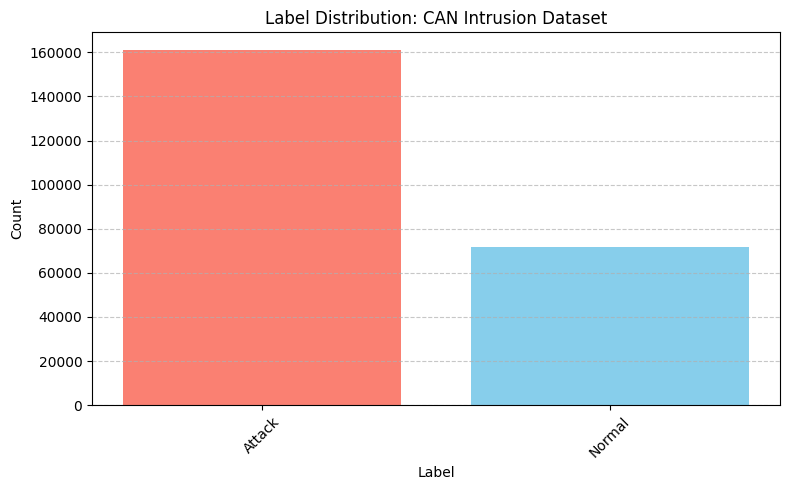

In [ ]:
import matplotlib.pyplot as plt

# Check label distribution
label_counts = df_CAN_Intrusion_final_dataset['Label'].value_counts()
print(label_counts)

# Color: blue for normal, red for attack
colors = ['skyblue' if str(label).lower() == 'normal' else 'salmon' for label in label_counts.index]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values, color=colors)
plt.title('Label Distribution: CAN Intrusion Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Balancing Dataset

In [ ]:
label_map = {'Normal': 0, 'Attack': 1}
df_CAN_Intrusion_final_dataset['Label'] = df_CAN_Intrusion_final_dataset['Label'].map(label_map)


In [ ]:
from sklearn.utils import resample

# Split the dataset
df_attack = df_CAN_Intrusion_final_dataset[df_CAN_Intrusion_final_dataset['Label'] == 1]
df_normal = df_CAN_Intrusion_final_dataset[df_CAN_Intrusion_final_dataset['Label'] == 0]

# Undersample attack class
df_attack_downsampled = resample(
    df_attack,
    replace=False,
    n_samples=len(df_normal),
    random_state=42
)

# Combine balanced data
df_CAN_Intrusion_balanced = pd.concat([df_normal, df_attack_downsampled], ignore_index=True)

# Shuffle
df_CAN_Intrusion_balanced = df_CAN_Intrusion_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


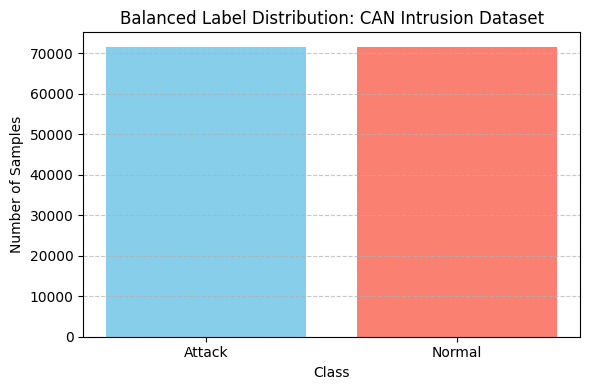

In [ ]:
import matplotlib.pyplot as plt

# Optional: add human-readable labels for plotting
label_map = {0: 'Normal', 1: 'Attack'}
df_CAN_Intrusion_balanced['Label_Name'] = df_CAN_Intrusion_balanced['Label'].map(label_map)

# Count label occurrences
label_counts = df_CAN_Intrusion_balanced['Label_Name'].value_counts()

# Plot
colors = ['skyblue', 'salmon']
plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values, color=colors)
plt.title('Balanced Label Distribution: CAN Intrusion Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Verifying value Counts

In [ ]:
print("Label distribution before saving:")
print(df_CAN_Intrusion_balanced['Label'].value_counts())


Label distribution before saving:
Label
1    71579
0    71579
Name: count, dtype: int64


In [ ]:
# Define save path
save_path = "/content/drive/MyDrive/Datasets/dropbox_dataset/df_CAN_Intrusion_final_dataset.csv"

# Save it
df_CAN_Intrusion_balanced.to_csv(save_path, index=False)

print(f"Balanced CAN Intrusion dataset saved to:\n{save_path}")


Balanced CAN Intrusion dataset saved to:
/content/drive/MyDrive/Datasets/dropbox_dataset/df_CAN_Intrusion_final_dataset.csv


In [ ]:
df_final_CAN_intrusion = pd.read_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_CAN_Intrusion_final_dataset.csv")

**Feature engineering**

In [ ]:
import numpy as np

df = df_final_CAN_intrusion.copy()

# Convert DATA0–7 to numeric (if not already)
for col in [f'DATA{i}' for i in range(8)]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Feature engineering on DATA0–7
data_cols = [f'DATA{i}' for i in range(8)]
df['DATA_mean'] = df[data_cols].mean(axis=1)
df['DATA_std'] = df[data_cols].std(axis=1)
df['DATA_sum'] = df[data_cols].sum(axis=1)
df['DATA_max'] = df[data_cols].max(axis=1)
df['DATA_min'] = df[data_cols].min(axis=1)
df['DATA_range'] = df['DATA_max'] - df['DATA_min']
df['DATA_entropy'] = df[data_cols].apply(lambda row: -np.sum((row / row.sum()) * np.log2((row / row.sum()) + 1e-9)), axis=1)

# Timestamp features
df = df.sort_values(by='Timestamp')
df['Time_Diff'] = df['Timestamp'].diff().fillna(0)
df['Time_Diff_Log'] = np.log1p(df['Time_Diff'])

# Final feature set
df_final_CAN_intrusion = df.copy()


Encode CAN_ID

In [ ]:
# Copy your original DataFrame
df = df_final_CAN_intrusion.copy()

# Convert CAN_ID from hex string to integer
df['CAN_ID_int'] = df['CAN_ID'].apply(lambda x: int(str(x), 16))

# Drop old CAN_ID (optional, since we'll use the integer version)
df.drop(columns=['CAN_ID'], inplace=True)


Feature preparation

In [ ]:
# Feature columns (excluding 'Label' and 'Label_Name')
feature_cols = ['Timestamp', 'DLC', 'CAN_ID_int'] + [f'DATA{i}' for i in range(8)]

# Prepare features and labels
X = df[feature_cols].values
y = df['Label'].values

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for Conv1D input: (samples, 1, features)
import numpy as np
X_dl = np.expand_dims(X_scaled, axis=1)

# Train-test split
from sklearn.model_selection import train_test_split
X_train_dl, X_test_dl, y_train, y_test = train_test_split(X_dl, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
import pandas as pd

# Start from the original dataframe
df_can = df_final_CAN_intrusion.copy()

# Label encoding if not already done
df_can['Label'] = df_can['Label'].astype(int)  # 0 for Normal, 1 for Attack

# Encode CAN_ID (hex to int)
df_can['CAN_ID_encoded'] = df_can['CAN_ID'].apply(lambda x: int(str(x), 16))

# Feature engineering on DATA0–DATA7
data_cols = [f'DATA{i}' for i in range(8)]
df_can['DATA_Sum'] = df_can[data_cols].sum(axis=1)
df_can['DATA_Mean'] = df_can[data_cols].mean(axis=1)
df_can['DATA_Std'] = df_can[data_cols].std(axis=1)
df_can['DATA_Max'] = df_can[data_cols].max(axis=1)
df_can['DATA_Min'] = df_can[data_cols].min(axis=1)
df_can['DATA_Range'] = df_can['DATA_Max'] - df_can['DATA_Min']
df_can['DATA_Median'] = df_can[data_cols].median(axis=1)
df_can['DATA_NonZero_Count'] = (df_can[data_cols] != 0).sum(axis=1)

# Drop unnecessary columns
df_final_can_clean = df_can.drop(columns=['Label_Name', 'CAN_ID'])

# Final ready-to-use dataframe
print("df_final_can_clean is ready.")
df_final_can_clean.head()


df_final_can_clean is ready.


,Timestamp,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,...,Time_Diff_Log,CAN_ID_encoded,DATA_Sum,DATA_Mean,DATA_Std,DATA_Max,DATA_Min,DATA_Range,DATA_Median,DATA_NonZero_Count
95135,0.059964,8,255,32,0,128,255,0,0,100,...,0.000000,880,770,96.250,109.116910,255,0,255,66.0,5
113963,0.059964,8,255,32,0,128,255,0,0,100,...,0.000000,880,770,96.250,109.116910,255,0,255,66.0,5
94095,0.059964,8,255,32,0,128,255,0,0,100,...,0.000000,880,770,96.250,109.116910,255,0,255,66.0,5
110786,0.063005,8,255,80,0,0,255,144,9,0,...,0.003036,1088,743,92.875,112.288452,255,0,255,44.5,5
2824,0.063005,8,255,80,0,0,255,144,9,0,...,0.000000,1088,743,92.875,112.288452,255,0,255,44.5,5


In [ ]:

# Save path in your Drive
save_path = "/content/drive/MyDrive/Datasets/dropbox_dataset/df_final_can_clean.csv"



# Save the DataFrame
df_final_can_clean.to_csv(save_path, index=False)

print(f"Saved to: {save_path}")


Saved to: /content/drive/MyDrive/Datasets/dropbox_dataset/df_final_can_clean.csv


Model Fitting

# ICUD (Healthcare Security Dataset)

we have 3 datasets
1. Attacks -contains Attack Network traffic in healthcare use case.
2. Environment Monitoring -contains environment sensors (Normal Network) traffic in healthcare use case.
3. Patient Monitoring - contains ICU patient monitoring sensors (Normal Network) traffic in healthcare use case.

In [ ]:
# Download the dataset from Kaggle
!kaggle datasets download -d faisalmalik/iot-healthcare-security-dataset

Dataset URL: https://www.kaggle.com/datasets/faisalmalik/iot-healthcare-security-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/16.1M [00:00<?, ?B/s]
100% 16.1M/16.1M [00:00<00:00, 679MB/s]


In [ ]:
# Unzip the downloaded zip file
!unzip -q iot-healthcare-security-dataset.zip -d iot_healthcare_dataset

In [ ]:
import os
import shutil

source_folder = "/content/iot_healthcare_dataset"
destination_folder = "/content/drive/MyDrive/Datasets/iot_healthcare_dataset"

# Ensure destination folder exists
os.makedirs(destination_folder, exist_ok=True)

# Copy everything inside, including subdirectories
for item in os.listdir(source_folder):
    src_path = os.path.join(source_folder, item)
    dst_path = os.path.join(destination_folder, item)

    if os.path.isdir(src_path):
        # If it's a folder, copy the whole directory
        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)
    else:
        # If it's a file, copy the file
        shutil.copy2(src_path, dst_path)

print(f" Entire unzipped dataset (including subfolders) saved to: {destination_folder}")


 Entire unzipped dataset (including subfolders) saved to: /content/drive/MyDrive/Datasets/iot_healthcare_dataset


In [ ]:
# Define paths
attack_path = "/content/drive/MyDrive/Datasets/iot_healthcare_dataset/ICUDatasetProcessed/Attack.csv"
env_path = "/content/drive/MyDrive/Datasets/iot_healthcare_dataset/ICUDatasetProcessed/environmentMonitoring.csv"
patient_path = "/content/drive/MyDrive/Datasets/iot_healthcare_dataset/ICUDatasetProcessed/patientMonitoring.csv"

In [ ]:

# Load datasets
df_attack = pd.read_csv(attack_path)
df_environment = pd.read_csv(env_path)
df_patient = pd.read_csv(patient_path)

Attacks Dataset

In [ ]:
# Quick preview of each dataset
print("Attack.csv")
df_attack.head()

Attack.csv


,frame.time_delta,frame.time_relative,frame.len,ip.src,ip.dst,tcp.srcport,tcp.dstport,tcp.flags,tcp.time_delta,tcp.len,...,mqtt.qos,mqtt.retain,mqtt.topic,mqtt.topic_len,mqtt.ver,mqtt.willmsg_len,ip.proto,ip.ttl,class,label
0,0.000000,0.000000,74,10.16.120.44,10.16.120.72,56808,1883,0x00000002,0.000000,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
1,0.000052,0.000052,74,10.16.120.72,10.16.120.44,1883,56808,0x00000012,0.000052,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
2,0.000008,0.000060,74,10.16.120.44,10.16.120.72,56810,1883,0x00000002,0.000000,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
3,0.000012,0.000072,74,10.16.120.72,10.16.120.44,1883,56810,0x00000012,0.000012,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
4,0.000003,0.000075,74,10.16.120.44,10.16.120.72,56812,1883,0x00000002,0.000000,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1


### Environment Monitoring Dataset

In [ ]:
print("\ Environment Monitoring")
df_environment.head()

\ Environment Monitoring


,frame.time_delta,frame.time_relative,frame.len,ip.src,ip.dst,tcp.srcport,tcp.dstport,tcp.flags,tcp.time_delta,tcp.len,...,mqtt.qos,mqtt.retain,mqtt.topic,mqtt.topic_len,mqtt.ver,mqtt.willmsg_len,ip.proto,ip.ttl,class,label
0,0.000000,0.000000,105,10.5.126.151,10.5.126.84,40629,1883,0x00000018,0.000000,37,...,0.0,0.0,0,0.0,4.0,0.0,6,64,environmentMonitoring,0
1,0.000053,0.000053,72,10.5.126.84,10.5.126.151,1883,40629,0x00000018,0.000053,4,...,0.0,0.0,0,0.0,0.0,0.0,6,64,environmentMonitoring,0
2,0.000043,0.000096,105,10.5.126.153,10.5.126.84,45639,1883,0x00000018,0.000000,37,...,0.0,0.0,0,0.0,4.0,0.0,6,64,environmentMonitoring,0
3,0.000020,0.000116,72,10.5.126.84,10.5.126.153,1883,45639,0x00000018,0.000020,4,...,0.0,0.0,0,0.0,0.0,0.0,6,64,environmentMonitoring,0
4,0.000016,0.000132,105,10.5.126.155,10.5.126.84,45093,1883,0x00000018,0.000000,37,...,0.0,0.0,0,0.0,4.0,0.0,6,64,environmentMonitoring,0


### Patient Monitoring

In [ ]:
print("Patient Monitoring")
df_patient.head()

Patient Monitoring


,frame.time_delta,frame.time_relative,frame.len,ip.src,ip.dst,tcp.srcport,tcp.dstport,tcp.flags,tcp.time_delta,tcp.len,...,mqtt.qos,mqtt.retain,mqtt.topic,mqtt.topic_len,mqtt.ver,mqtt.willmsg_len,ip.proto,ip.ttl,class,label
0,0.000000,0.000000,105,10.5.126.141,10.5.126.56,35161,1883,0x00000018,0.0,37,...,0.0,0.0,0,0.0,4.0,0.0,6,64,patientMonitoring,0
1,0.000249,0.000249,105,10.5.126.143,10.5.126.56,34237,1883,0x00000018,0.0,37,...,0.0,0.0,0,0.0,4.0,0.0,6,64,patientMonitoring,0
2,0.000037,0.000286,105,10.5.126.145,10.5.126.56,46623,1883,0x00000018,0.0,37,...,0.0,0.0,0,0.0,4.0,0.0,6,64,patientMonitoring,0
3,0.000034,0.000320,105,10.5.126.147,10.5.126.56,45663,1883,0x00000018,0.0,37,...,0.0,0.0,0,0.0,4.0,0.0,6,64,patientMonitoring,0
4,0.000017,0.000337,105,10.5.126.141,10.5.126.56,38901,1883,0x00000018,0.0,37,...,0.0,0.0,0,0.0,4.0,0.0,6,64,patientMonitoring,0


Merging the 3 datasets

When Merging its important to maintain data consistency therefore upon studying the 3 datasets we have to make a label for the environment and patient monitoring csv assuming to be normal occurency that is 0 while the attack csv remains to be label as 1

In [ ]:
#Adding a label column
# For environment_df, and Patient_df ensure 'label' is 0 for normal activity
# first of all we have to check if the label exists or not before adding
# If it exists, ensure all values are 0 if this dataset is purely normal traffic
if 'label' not in df_environment.columns:
    df_environment['label'] = 0
else:

    df_environment['label'] = 0

if 'label' not in df_patient.columns:
    df_patient['label'] = 0
else:

    df_patient['label'] = 0

# Concatenate the three DataFrames
merged_df = pd.concat([df_attack, df_environment, df_patient], ignore_index=True)

# Display the value counts of the 'label' column in the merged DataFrame to verify consistency
print("Value counts for 'label' in the merged dataset:")
print(merged_df['label'].value_counts())

# Save the merged DataFrame to a new CSV file
merged_df.to_csv('merged_hospital_dataset.csv', index=False)

print("\nDatasets merged successfully into 'merged_hospital_dataset.csv'")

Value counts for 'label' in the merged dataset:
label
0    108568
1     80126
Name: count, dtype: int64

Datasets merged successfully into 'merged_hospital_dataset.csv'


The Merged Dataset

In [ ]:
#df_merged_hospital_dataset = pd.read_csv("merged_hospital_dataset.csv")
df_merged_hospital_dataset= pd.read_csv("/content/drive/MyDrive/Datasets/iot_healthcare_dataset/df_hospitalmerged_dataset.csv")

In [ ]:
df_merged_hospital_dataset.head()

,frame.time_delta,frame.time_relative,frame.len,ip.src,ip.dst,tcp.srcport,tcp.dstport,tcp.flags,tcp.time_delta,tcp.len,...,mqtt.qos,mqtt.retain,mqtt.topic,mqtt.topic_len,mqtt.ver,mqtt.willmsg_len,ip.proto,ip.ttl,class,label
0,0.000000,0.000000,74,10.16.120.44,10.16.120.72,56808,1883,0x00000002,0.000000,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
1,0.000052,0.000052,74,10.16.120.72,10.16.120.44,1883,56808,0x00000012,0.000052,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
2,0.000008,0.000060,74,10.16.120.44,10.16.120.72,56810,1883,0x00000002,0.000000,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
3,0.000012,0.000072,74,10.16.120.72,10.16.120.44,1883,56810,0x00000012,0.000012,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
4,0.000003,0.000075,74,10.16.120.44,10.16.120.72,56812,1883,0x00000002,0.000000,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1


Cleaning

In [ ]:
df_merged_hospital_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188694 entries, 0 to 188693
Data columns (total 52 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   frame.time_delta       188694 non-null  float64
 1   frame.time_relative    188694 non-null  float64
 2   frame.len              188694 non-null  int64  
 3   ip.src                 188694 non-null  object 
 4   ip.dst                 188694 non-null  object 
 5   tcp.srcport            188694 non-null  int64  
 6   tcp.dstport            188694 non-null  int64  
 7   tcp.flags              188694 non-null  object 
 8   tcp.time_delta         188694 non-null  float64
 9   tcp.len                188694 non-null  int64  
 10  tcp.ack                188694 non-null  int64  
 11  tcp.connection.fin     188694 non-null  float64
 12  tcp.connection.rst     188694 non-null  float64
 13  tcp.connection.sack    188694 non-null  float64
 14  tcp.connection.syn     188694 non-nu

In [ ]:
df_merged_hospital_dataset.isnull().sum()

,0
frame.time_delta,0
frame.time_relative,0
frame.len,0
ip.src,0
ip.dst,0
tcp.srcport,0
tcp.dstport,0
tcp.flags,0
tcp.time_delta,0
tcp.len,0


checking the shape of merged dataset

In [ ]:
df_merged_hospital_dataset.shape

(188694, 52)

Heat map

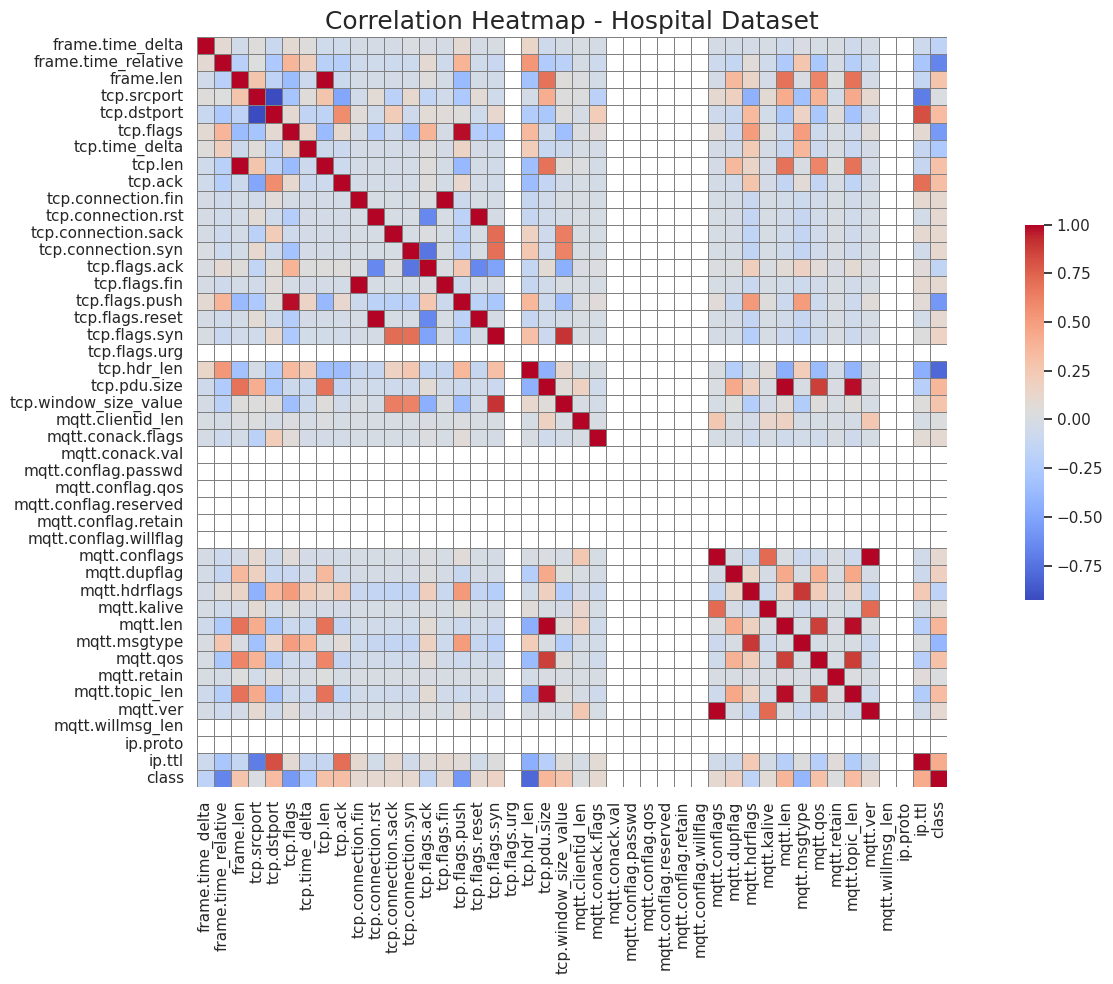

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="white")

# Drop non-numeric columns like IPs, flags, class labels, and strings
numeric_df = df_merged_hospital_dataset.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
corr = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='gray',
    square=True,
    cbar_kws={'shrink': 0.5}
)

plt.title("Correlation Heatmap - Hospital Dataset", fontsize=18)
plt.tight_layout()
plt.show()



Label Distribution

In [ ]:
label_counts = df_merged_hospital_dataset['label'].value_counts()
print(label_counts)


label
0    108568
1     80126
Name: count, dtype: int64


In [ ]:
# Map numeric labels to string for better visualization
df_merged_hospital_dataset['label'] = df_merged_hospital_dataset['label'].map({0: 'Normal', 1: 'Attack'})


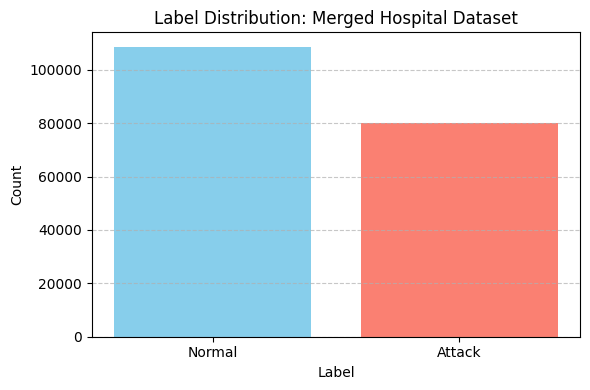

In [ ]:
import matplotlib.pyplot as plt

# Get value counts
label_counts = df_merged_hospital_dataset['label'].value_counts()
label_names = label_counts.index.astype(str)

# Color mapping
colors = ['skyblue' if label == 'Normal' else 'salmon' for label in label_names]

# Plot
plt.figure(figsize=(6, 4))
plt.bar(label_names, label_counts.values, color=colors)
plt.title('Label Distribution: Merged Hospital Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Balance Labels

In [ ]:
from sklearn.utils import resample

# Separate classes
df_normal = df_merged_hospital_dataset[df_merged_hospital_dataset['label'] == 'Normal']
df_attack = df_merged_hospital_dataset[df_merged_hospital_dataset['label'] == 'Attack']

# Upsample Attack to match Normal count
df_attack_upsampled = resample(
    df_attack,
    replace=True,
    n_samples=len(df_normal),
    random_state=42
)

# Combine and overwrite original DataFrame
df_merged_hospital_dataset = pd.concat([df_normal, df_attack_upsampled])
df_merged_hospital_dataset = df_merged_hospital_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df_merged_hospital_dataset['label'].value_counts()

,count
label,
Attack,108568
Normal,108568


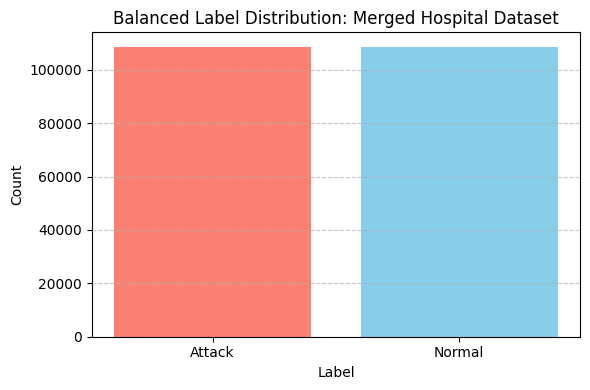

In [ ]:
import matplotlib.pyplot as plt

label_counts = df_merged_hospital_dataset['label'].value_counts()
colors = ['skyblue' if label == 'Normal' else 'salmon' for label in label_counts.index]

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values, color=colors)
plt.title('Balanced Label Distribution: Merged Hospital Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Saving our final Merged Dataset

In [ ]:
import os

# Set destination folder inside Google Drive
destination_folder = "/content/drive/MyDrive/Datasets/iot_healthcare_dataset"

# Make sure folder exists
os.makedirs(destination_folder, exist_ok=True)

# Full path to save
save_path = os.path.join(destination_folder, 'df_merged_hospital_dataset.csv')

# Save to CSV
df_merged_hospital_dataset.to_csv(save_path, index=False)

print(f"✅ Merged hospital dataset saved permanently at:\n{save_path}")


✅ Merged hospital dataset saved permanently at:
/content/drive/MyDrive/Datasets/iot_healthcare_dataset/df_merged_hospital_dataset.csv


In [ ]:
import pandas as pd
df_final_hospital = pd.read_csv("/content/drive/MyDrive/Datasets/iot_healthcare_dataset/df_merged_hospital_dataset.csv")

In [ ]:
df_final_hospital.head()

,frame.time_delta,frame.time_relative,frame.len,ip.src,ip.dst,tcp.srcport,tcp.dstport,tcp.flags,tcp.time_delta,tcp.len,...,mqtt.qos,mqtt.retain,mqtt.topic,mqtt.topic_len,mqtt.ver,mqtt.willmsg_len,ip.proto,ip.ttl,class,label
0,0.000001,20.313166,135,192.168.1.90,192.168.1.91,54564,1883,0x00000018,0.000001,81,...,1.0,0.0,mqtt-malaria/beem.loadr-MBP-di-Ivan-5.lan-5476...,66.0,0.0,0.0,6,64,Attack,Attack
1,0.000003,0.202427,66,10.16.120.44,10.16.120.72,57330,1883,0x00000010,0.000212,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,Attack
2,0.000000,58.707184,153,192.168.1.90,192.168.1.91,54564,1883,0x00000018,0.000000,99,...,1.0,0.0,mqtt-malaria/beem.loadr-MBP-di-Ivan-5.lan-5476...,66.0,0.0,0.0,6,64,Attack,Attack
3,0.000025,43.432620,54,192.168.1.90,192.168.1.91,54571,1883,0x00000010,0.000025,0,...,0.0,0.0,0,0.0,0.0,0.0,6,64,Attack,Attack
4,0.000187,4980.054272,70,10.5.126.167,10.5.126.56,33251,1883,0x00000018,1.007589,2,...,0.0,0.0,0,0.0,0.0,0.0,6,64,patientMonitoring,Normal


Data cleaning and preprocessing

In [ ]:
import pandas as pd

# Copy dataset
df_hospital = df_final_hospital.copy()

# Drop string/object columns that are not useful for deep learning
df_hospital = df_hospital.drop(columns=['ip.src', 'ip.dst', 'mqtt.topic', 'label'], errors='ignore')


In [ ]:
# Show object (categorical) columns
print("Categorical columns:", df_hospital.select_dtypes(include='object').columns.tolist())


Categorical columns: ['tcp.flags', 'tcp.payload', 'tcp.checksum', 'mqtt.clientid', 'mqtt.conack.flags', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.msg', 'class']


encoding

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Make a copy
df_hosp = df_final_hospital.copy()

# Drop very high-cardinality or non-informative columns
drop_cols = [
    'ip.src', 'ip.dst', 'mqtt.topic', 'mqtt.clientid',
    'mqtt.msg', 'tcp.payload', 'tcp.checksum', 'label'
]
df_hosp.drop(columns=drop_cols, errors='ignore', inplace=True)

# Label encode low-cardinality categorical columns
label_cols = ['tcp.flags', 'mqtt.conack.flags', 'mqtt.conflags', 'mqtt.hdrflags']
for col in label_cols:
    if df_hosp[col].dtype == 'object':
        le = LabelEncoder()
        df_hosp[col] = le.fit_transform(df_hosp[col].astype(str))

# Encode target
df_hosp['class'] = df_hosp['class'].apply(lambda x: 1 if x == 'Attack' else 0)

df_hosp.head()

,frame.time_delta,frame.time_relative,frame.len,tcp.srcport,tcp.dstport,tcp.flags,tcp.time_delta,tcp.len,tcp.ack,tcp.connection.fin,...,mqtt.len,mqtt.msgtype,mqtt.qos,mqtt.retain,mqtt.topic_len,mqtt.ver,mqtt.willmsg_len,ip.proto,ip.ttl,class
0,0.000001,20.313166,135,54564,1883,6,0.000001,81,12053,0.0,...,167.0,3.0,1.0,0.0,66.0,0.0,0.0,6,64,1
1,0.000003,0.202427,66,57330,1883,2,0.000212,0,5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,64,1
2,0.000000,58.707184,153,54564,1883,6,0.000000,99,26153,0.0,...,178.0,3.0,1.0,0.0,66.0,0.0,0.0,6,64,1
3,0.000025,43.432620,54,54571,1883,2,0.000025,0,19901,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,64,1
4,0.000187,4980.054272,70,33251,1883,6,1.007589,2,169,0.0,...,0.0,12.0,0.0,0.0,0.0,0.0,0.0,6,64,0


In [ ]:

# Save path in your Drive
save_path = "/content/drive/MyDrive/Datasets/iot_healthcare_dataset/df_hospitalmerged_dataset.csv"

# Save the DataFrame
df_hosp.to_csv(save_path, index=False)

print(f" Saved to: {save_path}")


 Saved to: /content/drive/MyDrive/Datasets/iot_healthcare_dataset/df_hospitalmerged_dataset.csv


# MERGED DATASET

###**Creteria for Merging datasets**

Now, the most crucial part of merging these diverse datasets: creating a unified label taxonomy. We'll map the various attack labels from each dataset to a common set of categories.

Proposed Master Attack Taxonomy:


**Normal** DoS (Denial of Service) - This will cover various forms of DoS.
Probe (Scanning, reconnaissance)


**R2L** (Remote to Local - unauthorized access from a remote machine)


**U2R** (User to Root - unauthorized access to local superuser privileges)
Spoofing (Impersonation)


**Other_Attack** (For anything that doesn't fit neatly, or if we don't have enough information from the snippets)


We will create a new column, Unified_Label, in each DataFrame.



1. **CAN Intrusion Dataset**

When loading the dataset since we are not planning to load all the dataset because of the size issue we have to randomly select a sample from the dataset by setting a limit of amount of data we want to load from the particular dataset before merging with the dataset.

Also in the process we have to make sure that when loading the dataset the samples we are loading are having a balanced labels so that each dataset will be equally represented from various domains and also interms of a balanced label distriubtion across the dataset

In [ ]:
# Load full dataset
#can_df = pd.read_csv('/content/drive/MyDrive/Datasets/dropbox_dataset/df_CAN_Intrusion_final_dataset.csv')
can_df =pd.read_csv("/content/drive/MyDrive/Datasets/dropbox_dataset/df_final_can_clean.csv")

In [ ]:
# Check label distribution
can_df['Label'].value_counts()

,count
Label,
0,71579
1,71579


Yes this shows that our value count for labels are balanced and thats what we are aiming for before we merge the dataset with the other ones from the other domains

2. Hospital dataset

In [ ]:
hospital_df1 = pd.read_csv("/content/drive/MyDrive/Datasets/iot_healthcare_dataset/df_hospitalmerged_dataset.csv")

In [ ]:
hospital_df1.head()

,frame.time_delta,frame.time_relative,frame.len,tcp.srcport,tcp.dstport,tcp.flags,tcp.time_delta,tcp.len,tcp.ack,tcp.connection.fin,...,mqtt.len,mqtt.msgtype,mqtt.qos,mqtt.retain,mqtt.topic_len,mqtt.ver,mqtt.willmsg_len,ip.proto,ip.ttl,class
0,0.000001,20.313166,135,54564,1883,6,0.000001,81,12053,0.0,...,167.0,3.0,1.0,0.0,66.0,0.0,0.0,6,64,1
1,0.000003,0.202427,66,57330,1883,2,0.000212,0,5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,64,1
2,0.000000,58.707184,153,54564,1883,6,0.000000,99,26153,0.0,...,178.0,3.0,1.0,0.0,66.0,0.0,0.0,6,64,1
3,0.000025,43.432620,54,54571,1883,2,0.000025,0,19901,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,64,1
4,0.000187,4980.054272,70,33251,1883,6,1.007589,2,169,0.0,...,0.0,12.0,0.0,0.0,0.0,0.0,0.0,6,64,0


In [ ]:
# Rename 'class' to 'label'
hospital_df1.rename(columns={'class': 'label'}, inplace=True)

In [ ]:
# For hospital dataset
#hospital_df1 = pd.read_csv("/content/drive/MyDrive/Datasets/iot_healthcare_dataset/df_merged_hospital_dataset.csv")
#hospital_df1 = pd.read_csv("/content/drive/MyDrive/Datasets/iot_healthcare_dataset/df_hospitalmerged_dataset.csv")

# Desired count per class
samples_per_class = 77000

# Stratified downsampling
hospital_df= (
    hospital_df1
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=samples_per_class, random_state=42))
    .reset_index(drop=True)
)

In [ ]:

hospital_df['label'].value_counts()

,count
label,
0,77000
1,77000


3. NSL_KDD Dataset

In [ ]:

# For NSL-KDD dataset
nslkdd_df = pd.read_csv("/content/drive/MyDrive/Datasets/nsl_kdd/df_nsl_kdd_merged_dataset.csv")

In [ ]:
nslkdd_df['label'].value_counts()

,count
label,
Normal,77054
Attack,77054


4. Iot Intrusion Dataset

In [ ]:
iot_df1 = pd.read_csv("/content/drive/MyDrive/Datasets/IoT/df_iot_intrusion_final_dataset.csv")

# Desired count per class
samples_per_class = 77000

# Stratified downsampling
iot_df= (
    iot_df1
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=samples_per_class, random_state=42))
    .reset_index(drop=True)
)


In [ ]:
iot_df['label'].value_counts()

,count
label,
Attack,77000
Normal,77000


**Feature engineering and harmonization**

Now that we have standardized labels, the next crucial step is to engineer features from each dataset that can be aligned into a common format. This is where we create a unified feature space.

Since the datasets are fundamentally different (CAN bus bytes vs. network flow stats vs. IoT packet details), we can't just directly merge columns. We need to:

**Extract relevant features from each dataset**.

**Transform features where necessary** (e.g., one-hot encode categorical data, derive statistical features).

Identify "**common meta-features**" that represent similar concepts across domains, even if derived differently.

Create a **consistent set of columns** for the final merged DataFrame, handling missing features for specific domains by filling with default values (like 0 or NaN).

**Creating a Unified label and adding domain identifier**

In [ ]:
can_df_fe = can_df.rename(columns={'Label': 'Unified_Label'})

In [ ]:
# Add domain identifier
can_df_fe ['Domain'] = 'CAN'

In [ ]:
can_df_fe.head()

,Timestamp,DLC,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,DATA6,DATA7,...,CAN_ID_encoded,DATA_Sum,DATA_Mean,DATA_Std,DATA_Max,DATA_Min,DATA_Range,DATA_Median,DATA_NonZero_Count,Domain
0,0.059964,8,255,32,0,128,255,0,0,100,...,880,770,96.250,109.116910,255,0,255,66.0,5,CAN
1,0.059964,8,255,32,0,128,255,0,0,100,...,880,770,96.250,109.116910,255,0,255,66.0,5,CAN
2,0.059964,8,255,32,0,128,255,0,0,100,...,880,770,96.250,109.116910,255,0,255,66.0,5,CAN
3,0.063005,8,255,80,0,0,255,144,9,0,...,1088,743,92.875,112.288452,255,0,255,44.5,5,CAN
4,0.063005,8,255,80,0,0,255,144,9,0,...,1088,743,92.875,112.288452,255,0,255,44.5,5,CAN


In [ ]:
can_df_fe['Unified_Label'].value_counts()

,count
Unified_Label,
0,71579
1,71579



**Feature engineering- NSL-KDD Dataset**

**Creating unified label and add domain identifier**

In [ ]:
nslkdd_df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'attack', 'level', 'label'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

def fe_nslkdd_data(df):
    print("Engineering features for NSL-KDD data...")

    # Standardize label column
    df = df.rename(columns={'label': 'Unified_Label'})

    # Drop irrelevant columns
    df = df.drop(columns=['attack', 'level'], errors='ignore')

    # Categorical columns to encode
    cat_cols = ['protocol_type', 'service', 'flag']

    # One-hot encode categorical features
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # Keep only numerical + encoded features + label
    final_cols = [col for col in df.columns if col != 'Unified_Label']
    nslkdd_engineered_df = df[final_cols + ['Unified_Label']].copy()

    # Add domain identifier
    nslkdd_engineered_df['Domain'] = 'Network_NSL-KDD'

    return nslkdd_engineered_df


Checking Label Distribution And shape

In [ ]:
nslkdd_df_fe = fe_nslkdd_data(nslkdd_df)

# Previe
nslkdd_df_fe.shape

Engineering features for NSL-KDD data...


(154108, 121)

In [ ]:
# Map 'Attack' to 1 and 'Normal' to 0
nslkdd_df_fe['Unified_Label'] = nslkdd_df_fe['Unified_Label'].map({'Normal': 0, 'Attack': 1})

In [ ]:
nslkdd_df_fe['Unified_Label'].value_counts()

,count
Unified_Label,
0,77054
1,77054


In [ ]:
nslkdd_df_fe.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,Unified_Label,Domain
0,0,222,1236,0,0,0,0,0,1,0,...,False,False,False,False,False,False,True,False,0,Network_NSL-KDD
1,0,54540,8314,0,0,0,2,0,1,1,...,False,False,False,False,False,False,True,False,1,Network_NSL-KDD
2,0,381,536,0,0,0,0,0,1,0,...,False,False,False,False,False,False,True,False,0,Network_NSL-KDD
3,0,44,110,0,0,0,0,0,0,0,...,False,False,False,False,False,False,True,False,0,Network_NSL-KDD
4,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,1,Network_NSL-KDD


Merged hopsital dataset

In [ ]:
hospital_df.columns

Index(['frame.time_delta', 'frame.time_relative', 'frame.len', 'tcp.srcport',
       'tcp.dstport', 'tcp.flags', 'tcp.time_delta', 'tcp.len', 'tcp.ack',
       'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.sack',
       'tcp.connection.syn', 'tcp.flags.ack', 'tcp.flags.fin',
       'tcp.flags.push', 'tcp.flags.reset', 'tcp.flags.syn', 'tcp.flags.urg',
       'tcp.hdr_len', 'tcp.pdu.size', 'tcp.window_size_value',
       'mqtt.clientid_len', 'mqtt.conack.flags', 'mqtt.conack.val',
       'mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved',
       'mqtt.conflag.retain', 'mqtt.conflag.willflag', 'mqtt.conflags',
       'mqtt.dupflag', 'mqtt.hdrflags', 'mqtt.kalive', 'mqtt.len',
       'mqtt.msgtype', 'mqtt.qos', 'mqtt.retain', 'mqtt.topic_len', 'mqtt.ver',
       'mqtt.willmsg_len', 'ip.proto', 'ip.ttl', 'label'],
      dtype='object')

Checking label distribution and shape

In [ ]:
hospital_df_fe= hospital_df.rename(columns={'label': 'Unified_Label'})

In [ ]:
hospital_df_fe['Domain'] = 'Healthcare'

In [ ]:
hospital_df_fe['Unified_Label'].value_counts()


,count
Unified_Label,
0,77000
1,77000


In [ ]:
hospital_df_fe.head()

,frame.time_delta,frame.time_relative,frame.len,tcp.srcport,tcp.dstport,tcp.flags,tcp.time_delta,tcp.len,tcp.ack,tcp.connection.fin,...,mqtt.msgtype,mqtt.qos,mqtt.retain,mqtt.topic_len,mqtt.ver,mqtt.willmsg_len,ip.proto,ip.ttl,Unified_Label,Domain
0,0.000027,1681.028124,86,33571,1883,6,1.000396,18,61,0.0,...,3.0,0.0,0.0,12.0,0.0,0.0,6,64,0,Healthcare
1,0.000065,6120.070606,70,1883,37701,6,0.000065,2,55322,0.0,...,13.0,0.0,0.0,0.0,0.0,0.0,6,64,0,Healthcare
2,0.000030,4201.033048,85,33921,1883,6,1.005547,17,145,0.0,...,3.0,0.0,0.0,11.0,0.0,0.0,6,64,0,Healthcare
3,0.000033,3305.033183,77,38323,1883,6,1.999353,9,115,0.0,...,3.0,0.0,0.0,3.0,0.0,0.0,6,64,0,Healthcare
4,0.000111,259.037928,86,35357,1883,6,2.007345,18,13,0.0,...,3.0,0.0,0.0,12.0,0.0,0.0,6,64,0,Healthcare


Feature enginering - iot intrusion dataset

In [ ]:
iot_df.columns

Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')

In [ ]:
def fe_iot_data(df):
    print(" Engineering features for IoT_General data...")

    # Step 1: Rename label column
    df = df.rename(columns={'label': 'Unified_Label'})

    # Step 2: Drop non-numeric or redundant protocol columns (optional)
    drop_cols = ['Protocol Type']  # drop this unless you plan to encode it later
    df = df.drop(columns=drop_cols, errors='ignore')

    # Step 3: Fill missing values with 0
    df = df.fillna(0)

    # Step 4: Add domain label
    df['Domain'] = 'IoT_General'

    return df


label distribution and shape

In [ ]:
iot_df_fe = fe_iot_data(iot_df)

# Previe
iot_df_fe.shape

 Engineering features for IoT_General data...


(154000, 47)

In [ ]:
# Map 'Attack' to 1 and 'Normal' to 0
iot_df_fe['Unified_Label'] = iot_df_fe['Unified_Label'].map({'Normal': 0, 'Attack': 1})


In [ ]:
iot_df_fe['Unified_Label'].value_counts()


,count
Unified_Label,
1,77000
0,77000


In [ ]:
iot_df_fe.head()

,flow_duration,Header_Length,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,Unified_Label,Domain
0,0.000000,55.76,65.91,2.119601,2.119601,0.0,0,0,0,1,...,55.76,83331043.46,9.5,10.485830,5.482925,167.918653,0.09,141.55,1,IoT_General
1,0.068005,20069.00,64.00,10346.854050,10346.854050,0.0,0,0,0,0,...,50.00,83102381.94,9.5,10.000000,0.000000,0.000000,0.00,141.55,1,IoT_General
2,1.655053,162.00,63.36,1.617923,1.617923,0.0,0,1,0,0,...,54.06,83361849.66,9.5,10.393232,0.057331,0.054789,0.03,141.55,1,IoT_General
3,14.448723,108.00,64.00,0.138421,0.138421,0.0,0,0,0,0,...,54.00,82942898.91,9.5,10.392305,0.000000,0.000000,0.00,141.55,1,IoT_General
4,0.000000,54.00,64.00,0.687635,0.687635,0.0,0,1,0,0,...,54.00,83487481.65,9.5,10.392305,0.000000,0.000000,0.00,141.55,1,IoT_General


Master Feature set

In [ ]:
# Define a Master Feature Set --
print("\n--- Defining Master Feature Set ---")

# Collect all unique feature names from all engineered DataFrames
all_engineered_columns = set()
all_engineered_columns.update(can_df_fe.columns.drop(['Unified_Label', 'Domain']))
all_engineered_columns.update(nslkdd_df_fe.columns.drop(['Unified_Label', 'Domain']))
all_engineered_columns.update(hospital_df_fe.columns.drop(['Unified_Label', 'Domain']))
all_engineered_columns.update(iot_df_fe.columns.drop(['Unified_Label', 'Domain']))

master_feature_set = sorted(list(all_engineered_columns))
print(f"Total number of master features: {len(master_feature_set)}")


--- Defining Master Feature Set ---
Total number of master features: 235


In [ ]:
# Align and Concatenate DataFrames (Memory-Optimized)
print("\n--- Aligning and Concatenating DataFrames (Memory Optimized) ---")

# Determine the final data types for the master DataFrame to optimize memory
# We'll aim for float32 for most numerical data and int8 for boolean-like features
dtype_mapping = {col: np.float32 for col in master_feature_set}
dtype_mapping['Unified_Label'] = 'category'
dtype_mapping['Domain'] = 'category'

# Initialize an empty list to store aligned DataFrames
merged_dfs_optimized = []

# List of DataFrames and their corresponding domain names
dfs_to_process = [
    (can_df_fe, 'CAN'),
    (nslkdd_df_fe, 'Network_NSL-KDD'),
    (hospital_df_fe, 'Healthcare'),
    (iot_df_fe, 'IoT_General')
]

for i, (df_fe, domain_name) in enumerate(dfs_to_process):
    print(f"Processing {domain_name} data (DataFrame {i+1}/{len(dfs_to_process)})...")

    # Create an empty DataFrame with the master feature set and desired dtypes
    # This avoids creating a copy of the original df_fe first with reindex
    aligned_df_temp = pd.DataFrame(index=df_fe.index, columns=master_feature_set + ['Unified_Label', 'Domain'])

    # Assign values from df_fe to aligned_df_temp for common columns
    common_cols = [col for col in df_fe.columns if col in aligned_df_temp.columns]
    aligned_df_temp[common_cols] = df_fe[common_cols]

    # Fill NaN for features that don't apply to a specific domain with 0
    # Use np.float32 or appropriate type for these newly filled columns
    cols_to_fill_zero = [col for col in master_feature_set if col not in df_fe.columns]
    for col in cols_to_fill_zero:
        aligned_df_temp[col] = 0.0 # Assign float directly, will be cast to float32 later

    # Assign Unified_Label and Domain
    aligned_df_temp['Unified_Label'] = df_fe['Unified_Label']
    aligned_df_temp['Domain'] = domain_name

    # Convert data types to optimize memory BEFORE appending
    for col, dtype in dtype_mapping.items():
        if col in aligned_df_temp.columns:
            # Handle potential conversion errors, especially with NaNs/0s if type is not float
            if dtype == np.float32 and aligned_df_temp[col].dtype != np.float32:
                 # Coerce to numeric first to handle potential non-numeric data, then to float32
                aligned_df_temp[col] = pd.to_numeric(aligned_df_temp[col], errors='coerce').astype(np.float32)
            elif dtype == 'category' and aligned_df_temp[col].dtype != 'category':
                aligned_df_temp[col] = aligned_df_temp[col].astype('category')
            elif aligned_df_temp[col].dtype != dtype:
                try:
                    aligned_df_temp[col] = aligned_df_temp[col].astype(dtype)
                except Exception as e:
                    print(f"Warning: Could not convert column {col} to {dtype} in {domain_name}: {e}")
                    # Fallback for problematic columns if needed, or keep original type

    merged_dfs_optimized.append(aligned_df_temp)

    # Explicitly delete the original engineered DataFrame and the temporary aligned_df_temp
    # This frees up memory as soon as possible.
    del df_fe
    del aligned_df_temp
    import gc # Import garbage collector
    gc.collect() # Force garbage collection


--- Aligning and Concatenating DataFrames (Memory Optimized) ---
Processing CAN data (DataFrame 1/4)...
Processing Network_NSL-KDD data (DataFrame 2/4)...
Processing Healthcare data (DataFrame 3/4)...
Processing IoT_General data (DataFrame 4/4)...


In [ ]:
# Final concatenation
print("\nPerforming final concatenation...")
final_merged_df = pd.concat(merged_dfs_optimized, ignore_index=True)

# Delete the list of individual DataFrames now that they are concatenated
del merged_dfs_optimized
gc.collect()

# Final check of data types after concatenation
for col, dtype in dtype_mapping.items():
    if col in final_merged_df.columns and final_merged_df[col].dtype != dtype:
        print(f"Post-concat Warning: Column {col} is {final_merged_df[col].dtype} not {dtype}")
        # Try to cast again if needed
        if dtype == np.float32:
            final_merged_df[col] = final_merged_df[col].astype(np.float32)
        elif dtype == 'category':
            final_merged_df[col] = final_merged_df[col].astype('category')


Performing final concatenation...
Post-concat Warning: Column Domain is object not category


In [ ]:
final_merged_df['Unified_Label'] = final_merged_df['Unified_Label'].astype('category')
final_merged_df['Domain'] = final_merged_df['Domain'].astype('category')


checking final merged dataset

In [ ]:
# shape
print("Dataset shape:", final_merged_df.shape)

Dataset shape: (605266, 237)


In [ ]:
#unique domains
print(final_merged_df['Domain'].value_counts())

Domain
Network_NSL-KDD    154108
Healthcare         154000
IoT_General        154000
CAN                143158
Name: count, dtype: int64


In [ ]:
#label Balance overall
print(final_merged_df['Unified_Label'].value_counts())

Unified_Label
0    302633
1    302633
Name: count, dtype: int64


In [ ]:
#preview sample rows
print(final_merged_df[['Domain', 'Unified_Label']].sample(5, random_state=108))

                 Domain Unified_Label
378628       Healthcare             1
329807       Healthcare             0
31423               CAN             0
236393  Network_NSL-KDD             1
433235       Healthcare             1


In [ ]:
#label balance per domain
print(final_merged_df.groupby('Domain')['Unified_Label'].value_counts())

Domain           Unified_Label
CAN              0                71579
                 1                71579
Healthcare       0                77000
                 1                77000
IoT_General      0                77000
                 1                77000
Network_NSL-KDD  0                77054
                 1                77054
Name: count, dtype: int64


The domain are now balanced in the dataset, while also the labels are balanced therefore making an ideal robust dataset to proceed with

In [ ]:
import os

# Define permanent path
destination_folder = "/content/drive/MyDrive/Datasets/unified_dataset2"
os.makedirs(destination_folder, exist_ok=True)

# Define full save path
save_path = os.path.join(destination_folder, "df_final_robust_intrusion_dataset2.csv")

# Save the file
final_merged_df.to_csv(save_path, index=False)

print(f"✅ Final merged dataset saved permanently at:\n{save_path}")


✅ Final merged dataset saved permanently at:
/content/drive/MyDrive/Datasets/unified_dataset2/df_final_robust_intrusion_dataset2.csv


#DATA CLEANING AND PREPROCESSING

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#df_unified = pd.read_csv("/content/drive/MyDrive/Datasets/unified_dataset/df_final_robust_intrusion_dataset.csv")
df_unified = pd.read_csv("/content/drive/MyDrive/Datasets/unified_dataset2/df_final_robust_intrusion_dataset2.csv")

In [ ]:
df_unified.head()

,ARP,AVG,CAN_ID_encoded,Covariance,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,...,tcp.len,tcp.pdu.size,tcp.srcport,tcp.time_delta,tcp.window_size_value,urg_count,urgent,wrong_fragment,Unified_Label,Domain
0,0.0,0.0,880.0,0.0,255.0,32.0,0.0,128.0,255.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,CAN
1,0.0,0.0,880.0,0.0,255.0,32.0,0.0,128.0,255.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,CAN
2,0.0,0.0,880.0,0.0,255.0,32.0,0.0,128.0,255.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CAN
3,0.0,0.0,1088.0,0.0,255.0,80.0,0.0,0.0,255.0,144.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,CAN
4,0.0,0.0,1088.0,0.0,255.0,80.0,0.0,0.0,255.0,144.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CAN


In [ ]:
df_unified.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605266 entries, 0 to 605265
Columns: 237 entries, ARP to Domain
dtypes: float64(235), int64(1), object(1)
memory usage: 1.1+ GB


In [ ]:
df_unified.dtypes

,0
ARP,float64
AVG,float64
CAN_ID_encoded,float64
Covariance,float64
DATA0,float64
...,...
urg_count,float64
urgent,float64
wrong_fragment,float64
Unified_Label,int64


checking for missing Values

In [ ]:
df_unified.isnull().sum()

,0
ARP,0
AVG,0
CAN_ID_encoded,0
Covariance,0
DATA0,0
...,...
urg_count,0
urgent,0
wrong_fragment,0
Unified_Label,0


duplicates

In [ ]:
duplicates = df_unified.duplicated()
duplicates.sum()

np.int64(118629)

In [ ]:
df_unified = df_unified.drop_duplicates()
#droping duplicated values

shape

In [ ]:
df_unified.shape

(605266, 237)

class distribution

In [ ]:
df_unified['Unified_Label'].value_counts()

,count
Unified_Label,
0,245860
1,240777


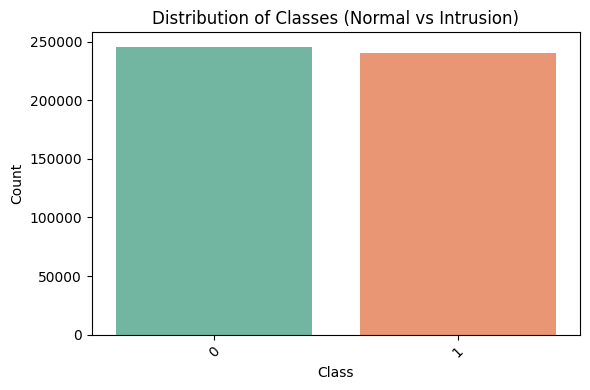

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_unified, x='Unified_Label', palette='Set2')
plt.title("Distribution of Classes (Normal vs Intrusion)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

Domain distribution

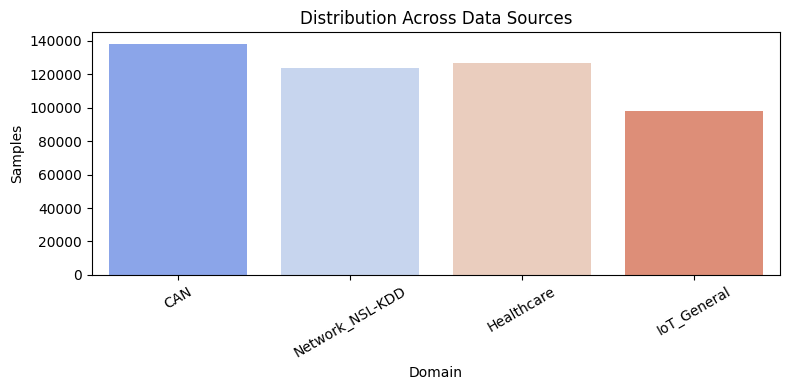

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_unified , x='Domain', palette='coolwarm')
plt.title("Distribution Across Data Sources")
plt.xlabel("Domain")
plt.ylabel("Samples")
plt.xticks(rotation=30)
plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
df_unified['Domain'].value_counts()


,count
Domain,
CAN,138177
Healthcare,126533
Network_NSL-KDD,123868
IoT_General,98059


class distribution per domain

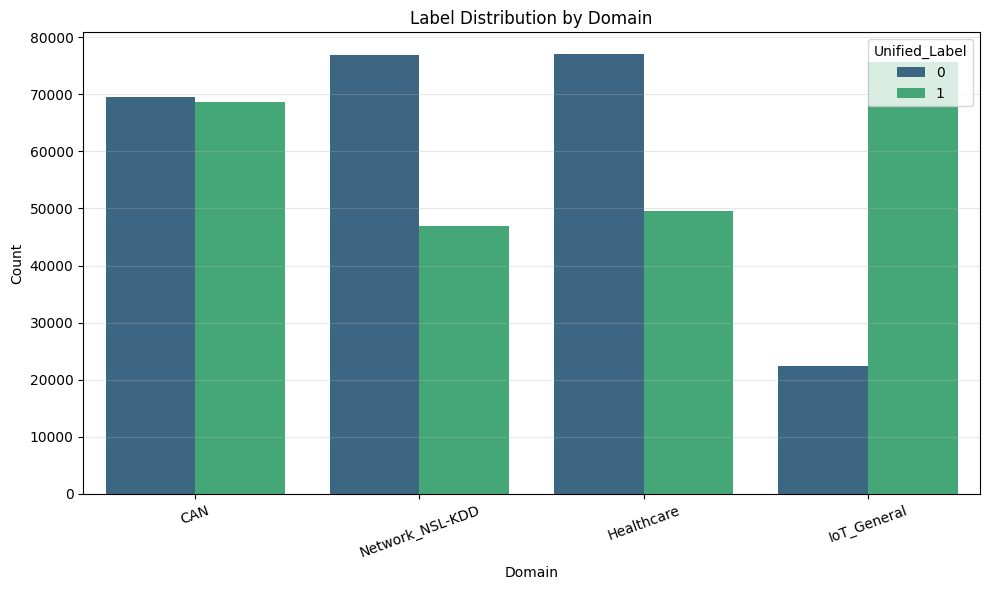

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_unified, x='Domain', hue='Unified_Label', palette='viridis')
plt.title("Label Distribution by Domain")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


statistical summary

In [ ]:
# Numeric columns only
numeric_df = df_unified.select_dtypes(include=['float64', 'int64'])

# Summary statistics
print("\nDescriptive statistics:\n")
display(numeric_df.describe().T)



Descriptive statistics:



,count,mean,std,min,25%,50%,75%,max
ARP,486637.0,0.000039,0.006248,0.0,0.0,0.0,0.0,1.000000e+00
AVG,486637.0,46.120536,213.039406,0.0,0.0,0.0,0.0,8.040961e+03
CAN_ID_encoded,486637.0,206.117003,386.866651,0.0,0.0,0.0,339.0,1.680000e+03
Covariance,486637.0,33486.689249,474912.027365,0.0,0.0,0.0,0.0,1.372844e+08
DATA0,486637.0,19.910284,59.995525,0.0,0.0,0.0,0.0,2.550000e+02
...,...,...,...,...,...,...,...,...
tcp.window_size_value,486637.0,567.908644,3572.591012,0.0,0.0,0.0,229.0,6.553500e+04
urg_count,486637.0,6.078261,51.581284,0.0,0.0,0.0,0.0,4.136700e+03
urgent,486637.0,0.000049,0.009509,0.0,0.0,0.0,0.0,3.000000e+00
wrong_fragment,486637.0,0.004243,0.109400,0.0,0.0,0.0,0.0,3.000000e+00


**Feature Correlation with label**

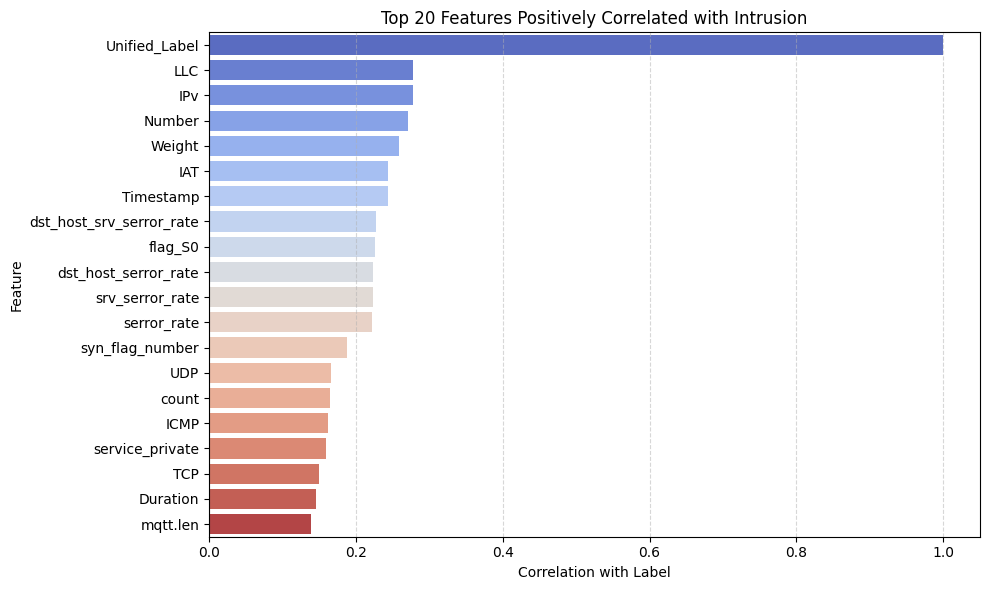

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Encode labels to numeric
df_unified['Label_Code'] = df_unified['Unified_Label'].astype('category').cat.codes

# Compute correlations
correlations = df_unified.corr(numeric_only=True)['Label_Code'].sort_values(ascending=False)

# Drop label itself and select top 20 correlated features
top_corr = correlations.drop('Label_Code').head(20)

# Generate a discrete color palette
palette = sns.color_palette("coolwarm", n_colors=len(top_corr))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette=palette)
plt.title("Top 20 Features Positively Correlated with Intrusion")
plt.xlabel("Correlation with Label")
plt.ylabel("Feature")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



***Feature Distribution***

import seaborn as sns
import matplotlib.pyplot as plt

features = ['DATA_Avg', 'DATA_Std', 'CAN_ID_Rate', 'tcp.len']

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df_unified, x=feature, hue='Unified_Label', fill=True, common_norm=False, palette='Set2')
    plt.title(f"{feature} Distribution by Binary Label")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


heatmap of feature correlations

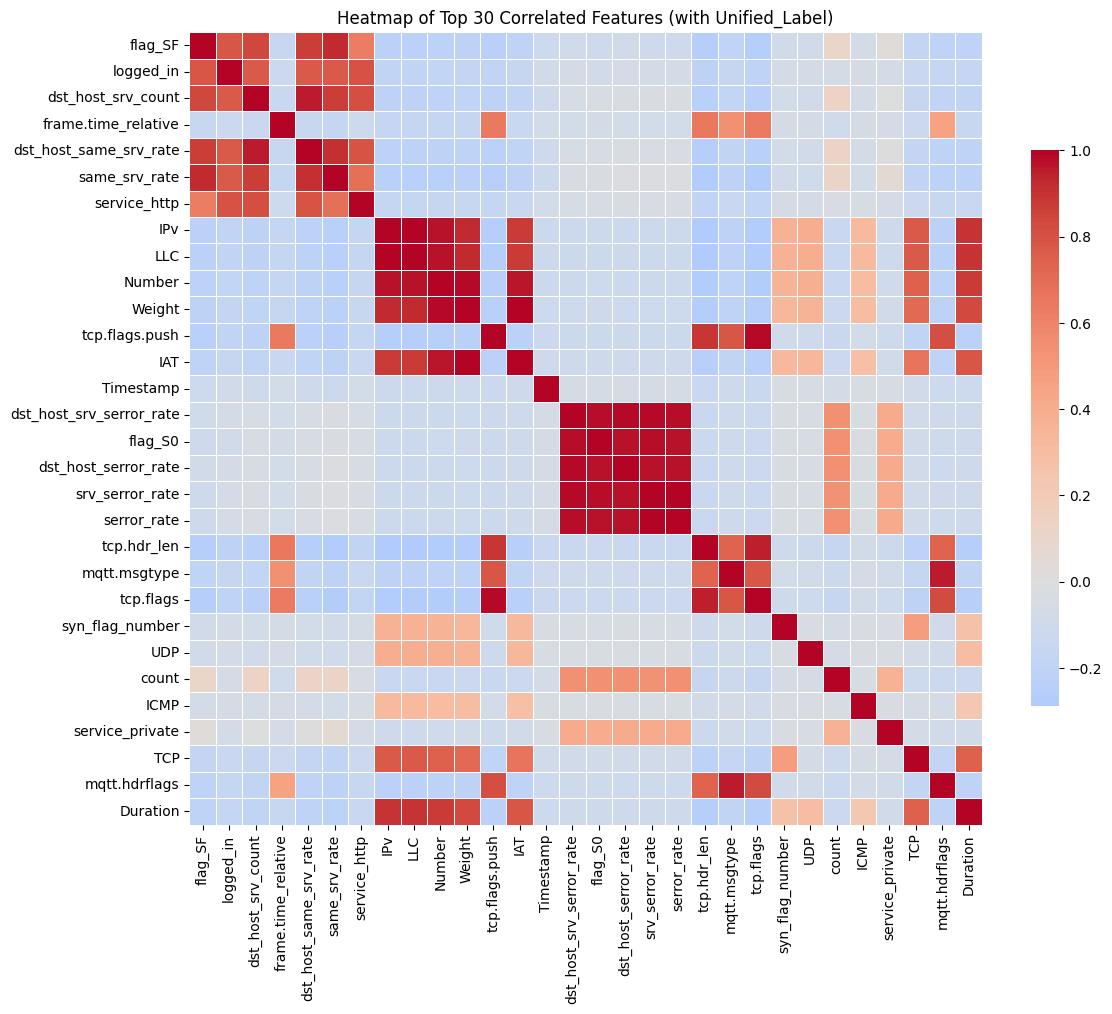

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric features (exclude Unified_Label)
numeric_features = df_unified.select_dtypes(include=['float64', 'int64']).drop(columns=['Unified_Label'])

# Correlate with the existing Unified_Label (0 = Normal, 1 = Attack)
correlations = numeric_features.corrwith(df_unified['Unified_Label']).abs().sort_values(ascending=False)

# Top 30 correlated features
top_features = correlations.head(30).index.tolist()

# Compute correlation matrix
corr_matrix = df_unified[top_features].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title("Heatmap of Top 30 Correlated Features (with Unified_Label)")
plt.tight_layout()
plt.show()





Feature skewness

 Feature Skewness:
 Time_Diff            697.593721
service_http_2784    697.593721
service_aol          697.593721
dst_bytes            627.291077
Time_Diff_Log        599.505214
service_harvest      493.271730
service_http_8001    493.271730
Drate                492.308646
num_compromised      480.520677
num_root             453.479613
dtype: float64


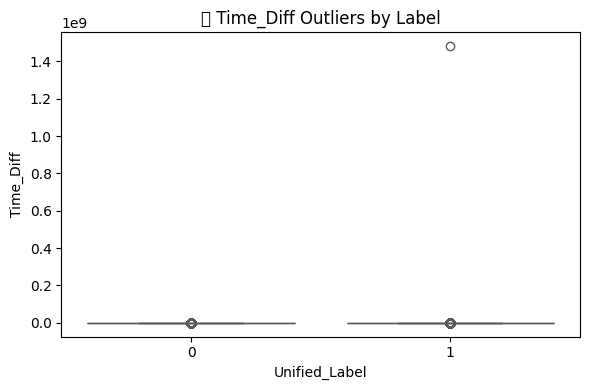

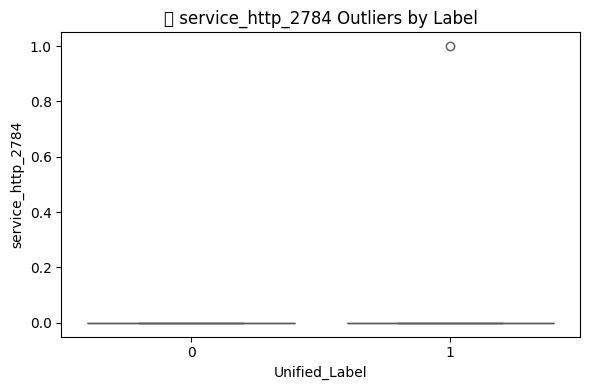

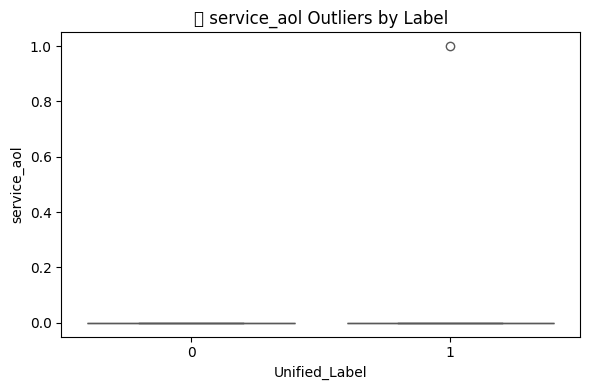

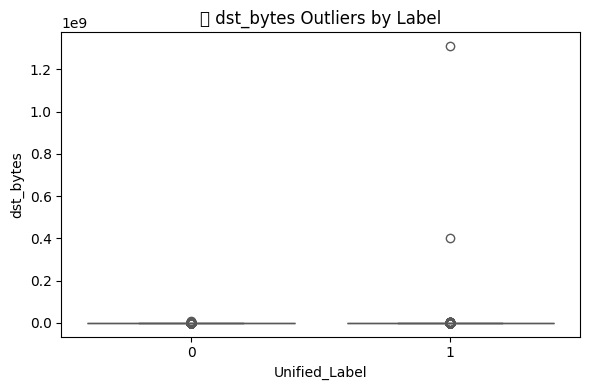

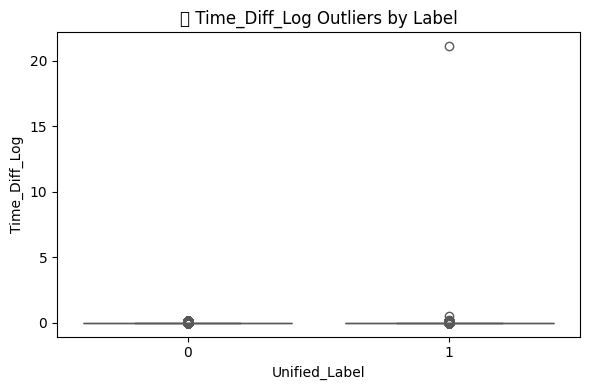

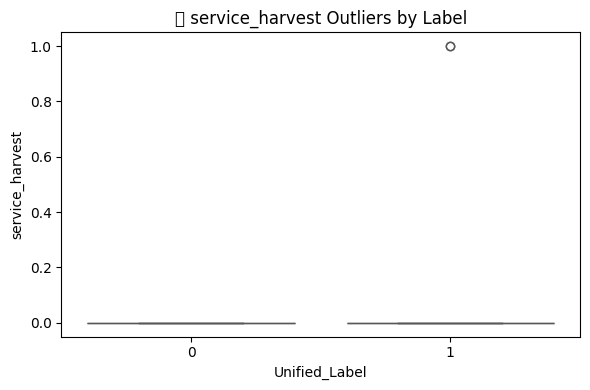

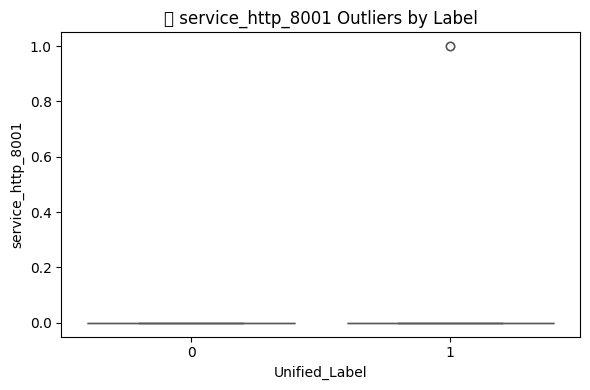

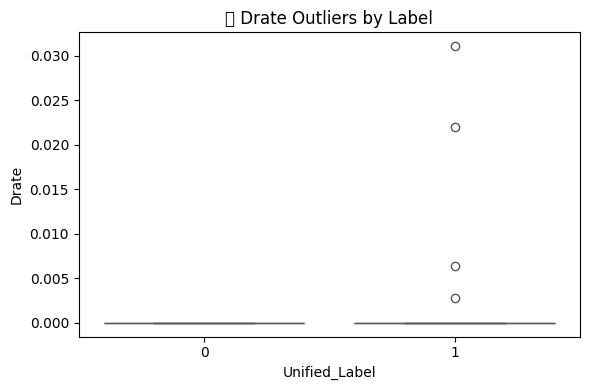

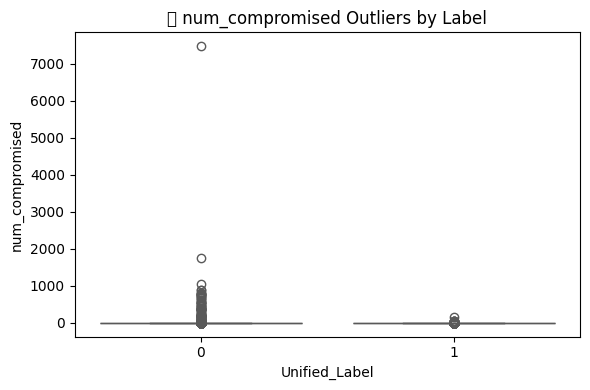

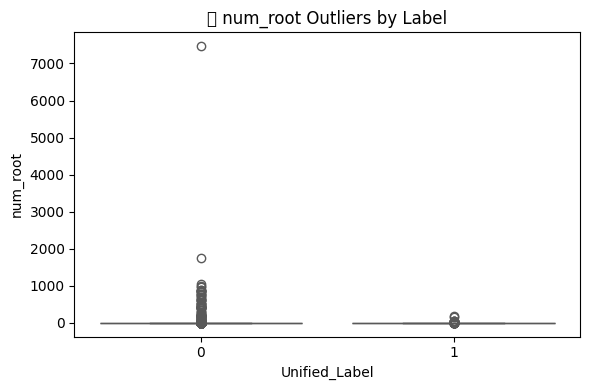

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute skewness on numerical columns
numeric_df = df_unified.select_dtypes(include=['float64', 'int64']).drop(columns=['Unified_Label'])
skewness = numeric_df.skew().sort_values(ascending=False)
print(" Feature Skewness:\n", skewness.head(10))

# Plot boxplots for top 10 skewed features
top_skewed_features = skewness.head(10).index.tolist()

for col in top_skewed_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_unified, x='Unified_Label', y=col, palette='Set2')
    plt.title(f"📦 {col} Outliers by Label")
    plt.tight_layout()
    plt.show()



Balancing Domain Distribution

In [ ]:
from sklearn.utils import resample

# Target sample size
target_count = 140322

# List to store resampled DataFrames
df_resampled = []

# Loop through each domain group
for domain, group_df in df_unified.groupby('Domain'):
    if len(group_df) < target_count:
        upsampled = resample(group_df,
                             replace=True,
                             n_samples=target_count,
                             random_state=42)
        df_resampled.append(upsampled)
    else:
        df_resampled.append(group_df)

# Concatenate and shuffle
df_final = pd.concat(df_resampled).sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
import os

# Define save path in your Drive
#save_path = "/content/drive/MyDrive/Datasets/unified_dataset/df_final_balanced_dataset.csv"
save_path = "/content/drive/MyDrive/Datasets/unified_dataset2/df_final_balanced_dataset2.csv"

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the DataFrame
df_final.to_csv(save_path, index=False)

print(f" Final balanced dataset saved permanently to:\n{save_path}")


✅ Final balanced dataset saved permanently to:
/content/drive/MyDrive/Datasets/unified_dataset2/df_final_balanced_dataset2.csv


In [ ]:
import pandas as pd
#df_final = pd.read_csv("/content/drive/MyDrive/Datasets/unified_dataset/df_final_balanced_dataset.csv")
df_final = pd.read_csv("/content/drive/MyDrive/Datasets/unified_dataset2/df_final_balanced_dataset2.csv")

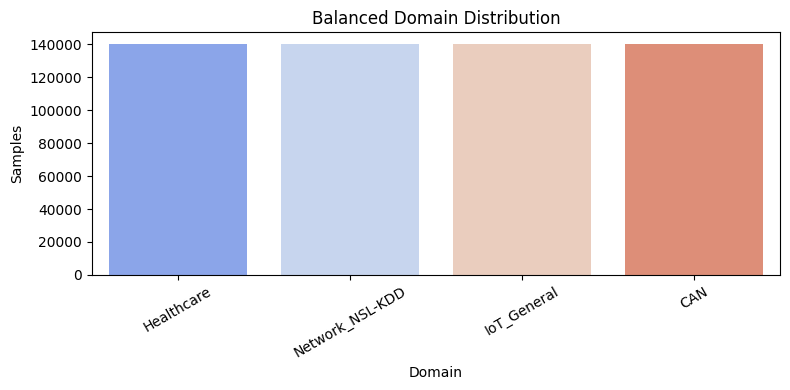

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Plot label distribution

plt.figure(figsize=(8, 4))
sns.countplot(data=df_final, x='Domain', palette='coolwarm')
plt.title("Balanced Domain Distribution")
plt.xlabel("Domain")
plt.ylabel("Samples")
plt.xticks(rotation=30)
plt.grid(False)
plt.tight_layout()
plt.show()


# ROBUST DATASET MODEL TRAINING AND TUNNING

In [ ]:
import pandas as pd


df = pd.read_csv('/content/drive/MyDrive/datasets/df_final_robust_intrusion_dataset2.csv')


In [ ]:
df.head()


,ARP,AVG,CAN_ID_encoded,Covariance,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,...,tcp.len,tcp.pdu.size,tcp.srcport,tcp.time_delta,tcp.window_size_value,urg_count,urgent,wrong_fragment,Unified_Label,Domain
0,0.0,0.0,880.0,0.0,255.0,32.0,0.0,128.0,255.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,CAN
1,0.0,0.0,880.0,0.0,255.0,32.0,0.0,128.0,255.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,CAN
2,0.0,0.0,1088.0,0.0,255.0,80.0,0.0,0.0,255.0,144.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,CAN
3,0.0,0.0,1088.0,0.0,255.0,80.0,0.0,0.0,255.0,144.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,CAN
4,0.0,0.0,688.0,0.0,21.0,0.0,0.0,7.0,139.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,CAN


In [ ]:
df.info()



KeyError: 'Label_Code'

In [ ]:
df.describe()

,ARP,AVG,CAN_ID_encoded,Covariance,DATA0,DATA1,DATA2,DATA3,DATA4,DATA5,...,tcp.hdr_len,tcp.len,tcp.pdu.size,tcp.srcport,tcp.time_delta,tcp.window_size_value,urg_count,urgent,wrong_fragment,Unified_Label
count,605266.000000,605266.000000,605266.000000,6.052660e+05,605266.000000,605266.000000,605266.000000,605266.000000,605266.000000,605266.000000,...,605266.000000,605266.000000,605266.000000,605266.000000,605266.000000,605266.000000,605266.000000,605266.000000,605266.00000,605266.0
mean,0.000084,93.129705,171.828822,8.842337e+04,16.595679,13.321650,15.221093,14.054102,15.222197,10.385373,...,6.869806,29.944697,8.389272,8993.566318,0.412404,680.010265,15.607735,0.000048,0.00555,0.5
std,0.009179,325.557141,361.564886,8.138854e+05,55.301765,43.028009,47.147323,48.142425,53.744296,42.080272,...,12.171218,187.334022,33.665858,18467.484841,3.132370,4019.418135,74.659281,0.009179,0.12502,0.5
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
25%,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
50%,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.5
75%,0.000000,42.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,20.000000,0.000000,0.000000,1883.000000,0.000000,227.000000,0.000000,0.000000,0.00000,1.0
max,1.000000,8040.961000,1680.000000,1.372844e+08,255.000000,254.000000,255.000000,255.000000,255.000000,255.000000,...,44.000000,1460.000000,695.000000,65471.000000,60.037327,65535.000000,4136.700000,3.000000,3.00000,1.0


CNN FOR FEATURE SELECTION

In [ ]:
df_final.columns

Index(['ARP', 'AVG', 'CAN_ID_encoded', 'Covariance', 'DATA0', 'DATA1', 'DATA2',
       'DATA3', 'DATA4', 'DATA5',
       ...
       'tcp.len', 'tcp.pdu.size', 'tcp.srcport', 'tcp.time_delta',
       'tcp.window_size_value', 'urg_count', 'urgent', 'wrong_fragment',
       'Unified_Label', 'Domain'],
      dtype='object', length=237)

Model fitting

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical



# Separate features and target
X = df.drop(columns=["Unified_Label", "Domain"])
y = df["Unified_Label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape y for binary classification
y_train = y_train.values
y_test = y_test.values


ANN

In [ ]:

from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix



# Compute class weights
cw = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

# Define the model
model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile
model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train
history = model_ann.fit(
    X_train, y_train,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8444 - loss: 0.3165 - val_accuracy: 0.9100 - val_loss: 0.1752
Epoch 2/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9090 - loss: 0.1835 - val_accuracy: 0.9125 - val_loss: 0.1694
Epoch 3/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9112 - loss: 0.1747 - val_accuracy: 0.9131 - val_loss: 0.1664
Epoch 4/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9126 - loss: 0.1702 - val_accuracy: 0.9137 - val_loss: 0.1648
Epoch 5/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9133 - loss: 0.1684 - val_accuracy: 0.9142 - val_loss: 0.1630
Epoch 6/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9135 - loss: 0.1668 - val_accuracy: 0.9143 - val_loss: 0.1621
Epoch 7/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9144 - loss: 0.1654 - val_accuracy: 0.9148 - val_loss: 0.1614
Epoch 8/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9142 - loss: 0.1646 - val_accuracy: 0

In [ ]:
# Predict and evaluate
y_pred = (model_ann.predict(X_test) > 0.5).astype("int32")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     49593
           1       1.00      0.83      0.91     48038

    accuracy                           0.92     97631
   macro avg       0.93      0.91      0.91     97631
weighted avg       0.93      0.92      0.91     97631

Confusion Matrix:
[[49491   102]
 [ 8193 39845]]


In [ ]:
y_proba = model_ann.predict(X_test)
y_pred_thresh = (y_proba > 0.4).astype(int)
print(classification_report(y_test, y_pred_thresh))
print(confusion_matrix(y_test, y_pred_thresh))


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     49593
           1       0.99      0.84      0.91     48038

    accuracy                           0.92     97631
   macro avg       0.93      0.91      0.91     97631
weighted avg       0.92      0.92      0.91     97631

[[49175   418]
 [ 7859 40179]]


In [ ]:
from sklearn.metrics import roc_auc_score

print("AUC-ROC Score:", roc_auc_score(y_test, y_proba))


AUC-ROC Score: 0.9772468949331323


CNN

In [ ]:
X_train_cnn = np.expand_dims(X_train, axis=2)
X_test_cnn = np.expand_dims(X_test, axis=2)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 186s 268ms/step - accuracy: 0.8703 - loss: 0.2729 - val_accuracy: 0.9108 - val_loss: 0.1746
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 200s 265ms/step - accuracy: 0.9096 - loss: 0.1807 - val_accuracy: 0.9127 - val_loss: 0.1686
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 198s 260ms/step - accuracy: 0.9102 - loss: 0.1760 - val_accuracy: 0.9131 - val_loss: 0.1672
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 200s 257ms/step - accuracy: 0.9114 - loss: 0.1734 - val_accuracy: 0.9131 - val_loss: 0.1652
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 178s 259ms/step - accuracy: 0.9123 - loss: 0.1714 - val_accuracy: 0.9139 - val_loss: 0.1651
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 202s 259ms/step - accuracy: 0.9117 - loss: 0.1704 - val_accuracy: 0.9142 - val_loss: 0.1643
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 202s 259ms/step - accuracy: 0.9129 - loss: 0.1683 - val_accuracy: 0.9148 - val_loss: 0.1638
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 177s 257ms/step - accuracy: 0.9127 -

In [ ]:
from tensorflow.keras.layers import LSTM

model_hybrid = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_hybrid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_hybrid = model_hybrid.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 469s 676ms/step - accuracy: 0.7365 - loss: 0.4707 - val_accuracy: 0.8901 - val_loss: 0.2348
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 488s 657ms/step - accuracy: 0.8836 - loss: 0.2459 - val_accuracy: 0.8998 - val_loss: 0.2024
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 499s 654ms/step - accuracy: 0.8731 - loss: 0.2701 - val_accuracy: 0.9011 - val_loss: 0.2007
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 505s 659ms/step - accuracy: 0.8977 - loss: 0.2144 - val_accuracy: 0.9028 - val_loss: 0.1899
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 449s 654ms/step - accuracy: 0.9001 - loss: 0.2009 - val_accuracy: 0.9039 - val_loss: 0.1915
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 502s 654ms/step - accuracy: 0.9042 - loss: 0.1897 - val_accuracy: 0.9051 - val_loss: 0.1834
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 506s 660ms/step - accuracy: 0.9063 - loss: 0.1875 - val_accuracy: 0.9091 - val_loss: 0.1764
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 502s 660ms/step - accuracy: 0.9078 -

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict
y_pred_cnn = (model_cnn.predict(X_test_cnn) > 0.5).astype("int32")
y_pred_hybrid = (model_hybrid.predict(X_test_cnn) > 0.5).astype("int32")

# Evaluation
print("CNN Model")
print(classification_report(y_test, y_pred_cnn))
print(confusion_matrix(y_test, y_pred_cnn))

print("CNN + LSTM Hybrid Model")
print(classification_report(y_test, y_pred_hybrid))
print(confusion_matrix(y_test, y_pred_hybrid))


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 72s 24ms/step
CNN Model
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     49593
           1       1.00      0.83      0.91     48038

    accuracy                           0.91     97631
   macro avg       0.93      0.91      0.91     97631
weighted avg       0.93      0.91      0.91     97631

[[49474   119]
 [ 8196 39842]]
CNN + LSTM Hybrid Model
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     49593
           1       0.99      0.83      0.90     48038

    accuracy                           0.91     97631
   macro avg       0.92      0.91      0.91     97631
weighted avg       0.92      0.91      0.91     97631

[[49334   259]
 [ 8314 39724]]


PERFOMANCE METRICS ANALYSIS

Ploting training vs loss validation

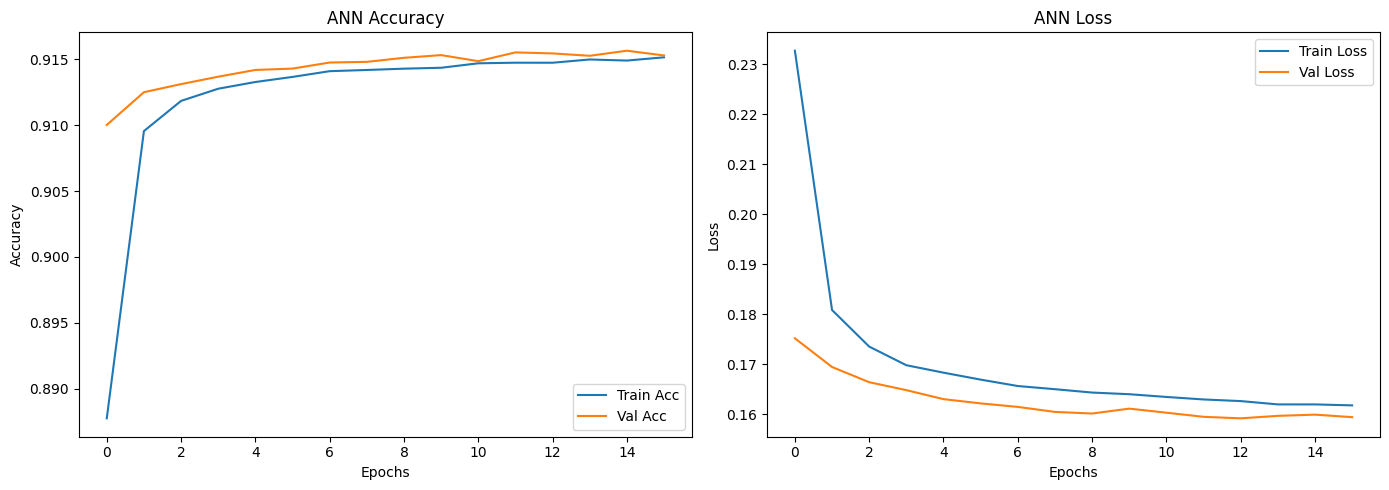

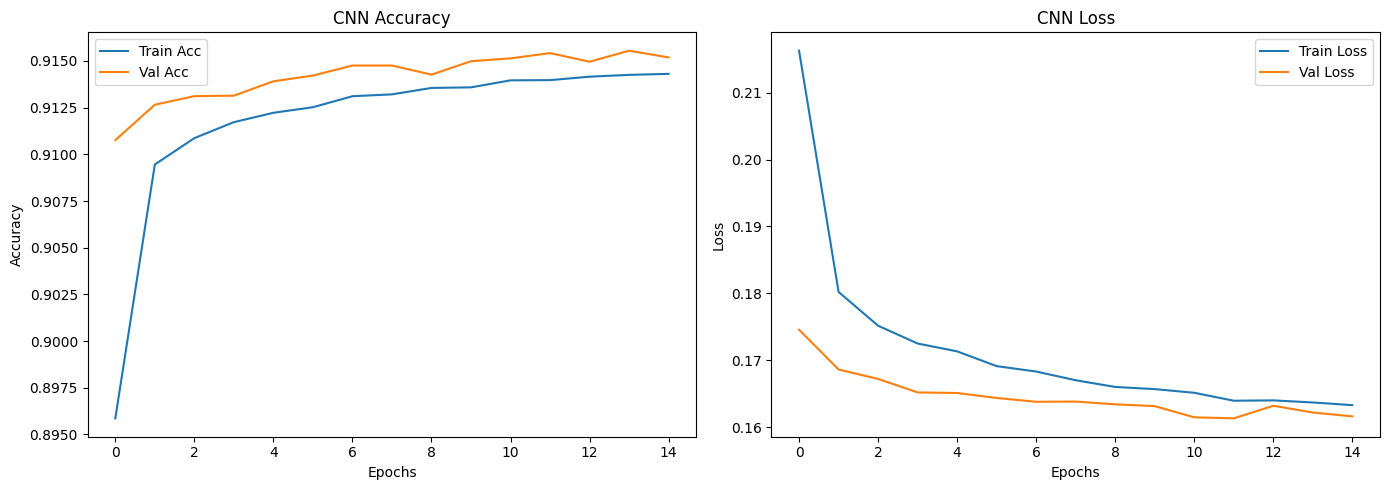

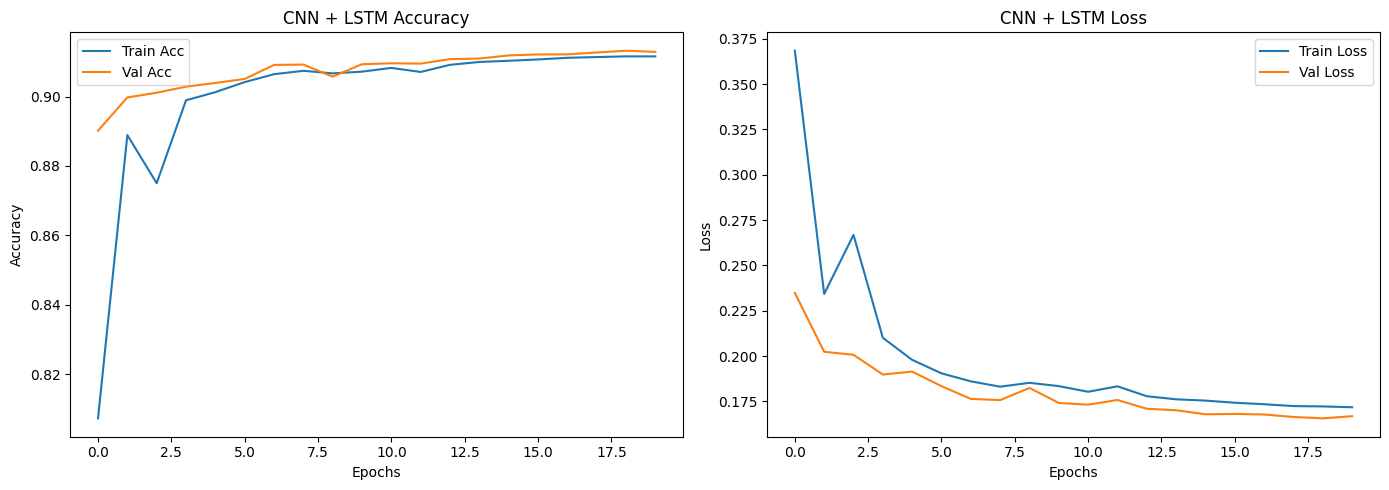

In [ ]:
import matplotlib.pyplot as plt

def plot_training(history, model_name):
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call for each:
plot_training(history, "ANN")
plot_training(history_cnn, "CNN")
plot_training(history_hybrid, "CNN + LSTM")


ROC and AUC

3051/3051 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 65s 21ms/step


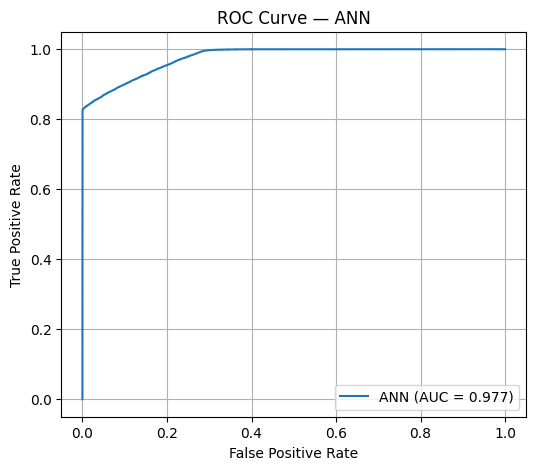

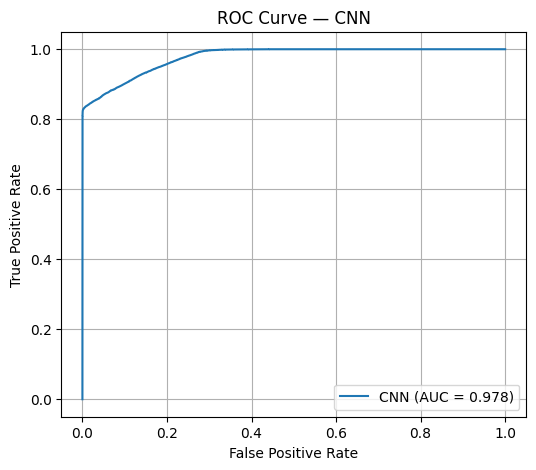

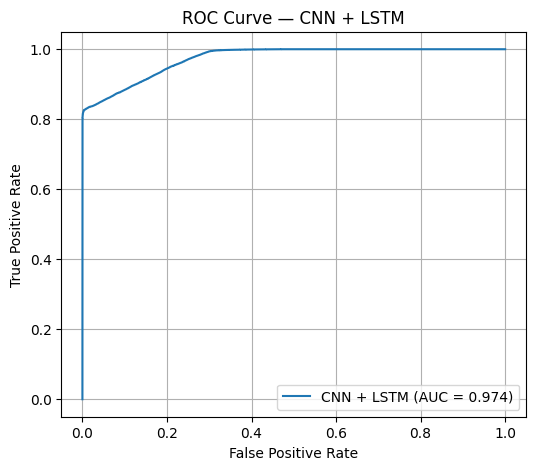

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc(y_true, y_scores, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')
    #plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {model_name}')
    plt.legend()
    plt.grid(True)
    plt.show()

    return auc_score

# Predict probabilities
y_score_ann = model_ann.predict(X_test)
y_score_cnn = model_cnn.predict(X_test_cnn)
y_score_hybrid = model_hybrid.predict(X_test_cnn)

auc_ann = plot_roc(y_test, y_score_ann, "ANN")
auc_cnn = plot_roc(y_test, y_score_cnn, "CNN")
auc_hybrid = plot_roc(y_test, y_score_hybrid, "CNN + LSTM")


Comparison table

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

# Binary predictions
y_pred_ann = (y_score_ann > 0.5).astype(int)
y_pred_cnn = (y_score_cnn > 0.5).astype(int)
y_pred_hybrid = (y_score_hybrid > 0.5).astype(int)

# Evaluate
results = {
    "ANN": evaluate_model(y_test, y_pred_ann, y_score_ann),
    "CNN": evaluate_model(y_test, y_pred_cnn, y_score_cnn),
    "CNN + LSTM": evaluate_model(y_test, y_pred_hybrid, y_score_hybrid)
}

# Convert to DataFrame
results_df = pd.DataFrame(results).T
print("\nModel Comparison Table:\n")
print(results_df.round(4))



Model Comparison Table:

            Accuracy  Precision  Recall  F1 Score     AUC
ANN           0.9150     0.9974  0.8294    0.9057  0.9772
CNN           0.9148     0.9970  0.8294    0.9055  0.9778
CNN + LSTM    0.9122     0.9935  0.8269    0.9026  0.9735


Ensemble the models

We’ll average the predicted probabilities from all three models and then apply a threshold to classify:

Final_prob
=
1
/
3
(
P Ann
+
P Cnn
+
P Hybrid
)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predict probabilities
y_prob_ann = model_ann.predict(X_test)
y_prob_cnn = model_cnn.predict(X_test_cnn)
y_prob_hybrid = model_hybrid.predict(X_test_cnn)

# Soft voting ensemble
ensemble_probs = (y_prob_ann + y_prob_cnn + y_prob_hybrid) / 3

# Apply threshold (default = 0.5)
ensemble_preds = (ensemble_probs > 0.5).astype(int)

# Evaluate
print(" Ensemble Model Performance:\n")
print(classification_report(y_test, ensemble_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, ensemble_preds))
print("ROC-AUC Score:", roc_auc_score(y_test, ensemble_probs))


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 66s 22ms/step
 Ensemble Model Performance:

              precision    recall  f1-score   support

           0       0.86      1.00      0.92     49593
           1       1.00      0.83      0.91     48038

    accuracy                           0.92     97631
   macro avg       0.93      0.91      0.91     97631
weighted avg       0.93      0.92      0.91     97631

Confusion Matrix:
 [[49475   118]
 [ 8159 39879]]
ROC-AUC Score: 0.9778546040820406


Tune threshold

In [ ]:
for thresh in [0.4, 0.45, 0.5, 0.55, 0.6]:
    preds = (ensemble_probs > thresh).astype(int)
    recall = recall_score(y_test, preds)
    print(f"Threshold {thresh} → Recall: {recall:.4f}")


Threshold 0.4 → Recall: 0.8383
Threshold 0.45 → Recall: 0.8318
Threshold 0.5 → Recall: 0.8302
Threshold 0.55 → Recall: 0.8296
Threshold 0.6 → Recall: 0.8283


ensemble ROC

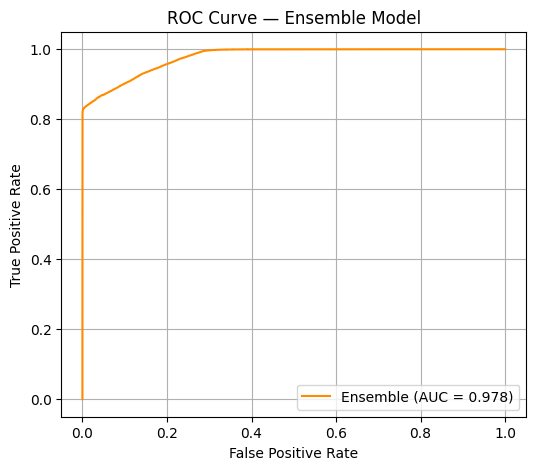

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, ensemble_probs)
auc_score = roc_auc_score(y_test, ensemble_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {auc_score:.3f})', color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Ensemble Model')
plt.legend()
plt.grid(True)
plt.show()


### **saving model for deployment**

In [ ]:
#saving each model
model_ann.save("model_ann.keras")
model_cnn.save("model_cnn.keras")
model_hybrid.save("model_hybrid.keras")



importing

In [ ]:
from tensorflow.keras.models import load_model

model_ann = load_model("model_ann.keras")
model_cnn = load_model("model_cnn.keras")
model_hybrid = load_model("model_hybrid.keras")


inference script

In [ ]:
# ensemble_inference.py
import numpy as np
from tensorflow.keras.models import load_model

# Load models once
model_ann = load_model("model_ann.h5")
model_cnn = load_model("model_cnn.h5")
model_hybrid = load_model("model_hybrid.h5")

def ensemble_predict(X_raw, scaler):
    # Preprocess
    X_scaled = scaler.transform(X_raw)
    X_cnn = np.expand_dims(X_scaled, axis=2)

    # Predict probabilities
    p_ann = model_ann.predict(X_scaled)
    p_cnn = model_cnn.predict(X_cnn)
    p_hybrid = model_hybrid.predict(X_cnn)

    # Average
    p_final = (p_ann + p_cnn + p_hybrid) / 3
    return (p_final > 0.5).astype(int), p_final
